[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/polsitoooo/Ingenieria-Del-Conocimiento/blob/main/Tareas_Ejercicios/Semana4/modelos_clasificacion_PolmarBrice%C3%B1o__I_resuelto(Dataset%20cancer%20Wisconsin).ipynb)

# Sesión 02 — Modelos de Clasificación
**Curso:** Ingeniería del Conocimiento (ISO56B)  
**Docente:** Msc. Jaime Antonio Huaytalla Pariona  
**Periodo:** 2026-II | Universidad Nacional del Centro del Perú  

---

## Objetivo
Implementar, comparar y analizar cuatro modelos fundamentales de clasificación supervisada — **Regresión Logística, Árbol de Decisión, SVM y KNN** — sobre el dataset **Wine Quality** de UCI, evaluando sus fortalezas, limitaciones y sensibilidad al preprocesamiento.

## 1. Configuración del entorno

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import (
    train_test_split, cross_val_score, StratifiedKFold, GridSearchCV
)
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix,
    ConfusionMatrixDisplay, RocCurveDisplay,
    accuracy_score, f1_score
)
from sklearn.inspection import DecisionBoundaryDisplay

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['figure.dpi'] = 100

RANDOM_STATE = 42
print('Entorno configurado correctamente.')

Entorno configurado correctamente.


---
## 2. Carga y comprensión del dataset

Utilizamos el **Wine Quality (Red)** del repositorio UCI Machine Learning. Contiene 1599 muestras de vino tinto portugués con 11 atributos fisicoquímicos y una puntuación de calidad (3–8).

Para construir un problema de **clasificación binaria**, definimos:
- **Clase 1 (Bueno):** calidad ≥ 7
- **Clase 0 (Estándar):** calidad < 7

Esta binarización genera un **problema desbalanceado**, lo que añade un reto realista al modelado.

In [ ]:
# Carga directa desde UCI
URL = 'https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv'

df = pd.read_csv(URL, sep=';')
print(f'Dataset cargado: {df.shape[0]} registros, {df.shape[1]} columnas')
df.head()

Dataset cargado: 1599 registros, 12 columnas


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


Distribución de calidad original:
quality
3     10
4     53
5    681
6    638
7    199
8     18
Name: count, dtype: int64


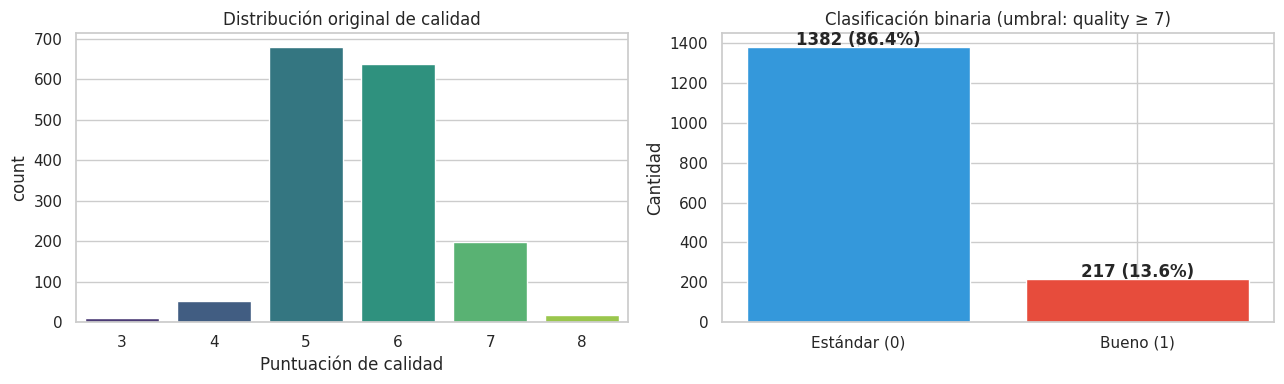


Ratio de desbalance: 6.4:1 (Estándar vs Bueno)


In [ ]:
# Distribución original de la variable 'quality'
print('Distribución de calidad original:')
print(df['quality'].value_counts().sort_index())

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Histograma original
sns.countplot(data=df, x='quality', ax=axes[0], palette='viridis')
axes[0].set_title('Distribución original de calidad')
axes[0].set_xlabel('Puntuación de calidad')

# Binarización
df['quality_label'] = (df['quality'] >= 7).astype(int)

counts = df['quality_label'].value_counts()
axes[1].bar(['Estándar (0)', 'Bueno (1)'], counts.values,
            color=['#3498db', '#e74c3c'])
for i, v in enumerate(counts.values):
    axes[1].text(i, v + 10, f'{v} ({v/len(df)*100:.1f}%)', ha='center', fontweight='bold')
axes[1].set_title('Clasificación binaria (umbral: quality ≥ 7)')
axes[1].set_ylabel('Cantidad')

plt.tight_layout()
plt.show()

print(f'\nRatio de desbalance: {counts[0]/counts[1]:.1f}:1 (Estándar vs Bueno)')

---
## 3. Análisis exploratorio orientado a clasificación

In [ ]:
# 3.1  Estadísticas descriptivas por clase
features = df.columns.drop(['quality', 'quality_label'])

comparison = df.groupby('quality_label')[features].mean().T
comparison.columns = ['Estándar (0)', 'Bueno (1)']
comparison['Diferencia %'] = ((comparison['Bueno (1)'] - comparison['Estándar (0)']) / comparison['Estándar (0)'] * 100).round(1)
comparison.style.background_gradient(subset=['Diferencia %'], cmap='RdYlGn')

,Estándar (0),Bueno (1),Diferencia %
fixed acidity,8.236831,8.847005,7.400000
volatile acidity,0.547022,0.405530,-25.900000
citric acid,0.254407,0.376498,48.000000
residual sugar,2.512120,2.708756,7.800000
chlorides,0.089281,0.075912,-15.000000
free sulfur dioxide,16.172214,13.981567,-13.500000
total sulfur dioxide,48.285818,34.889401,-27.700000
density,0.996859,0.996030,-0.100000
pH,3.314616,3.288802,-0.800000
sulphates,0.644754,0.743456,15.300000


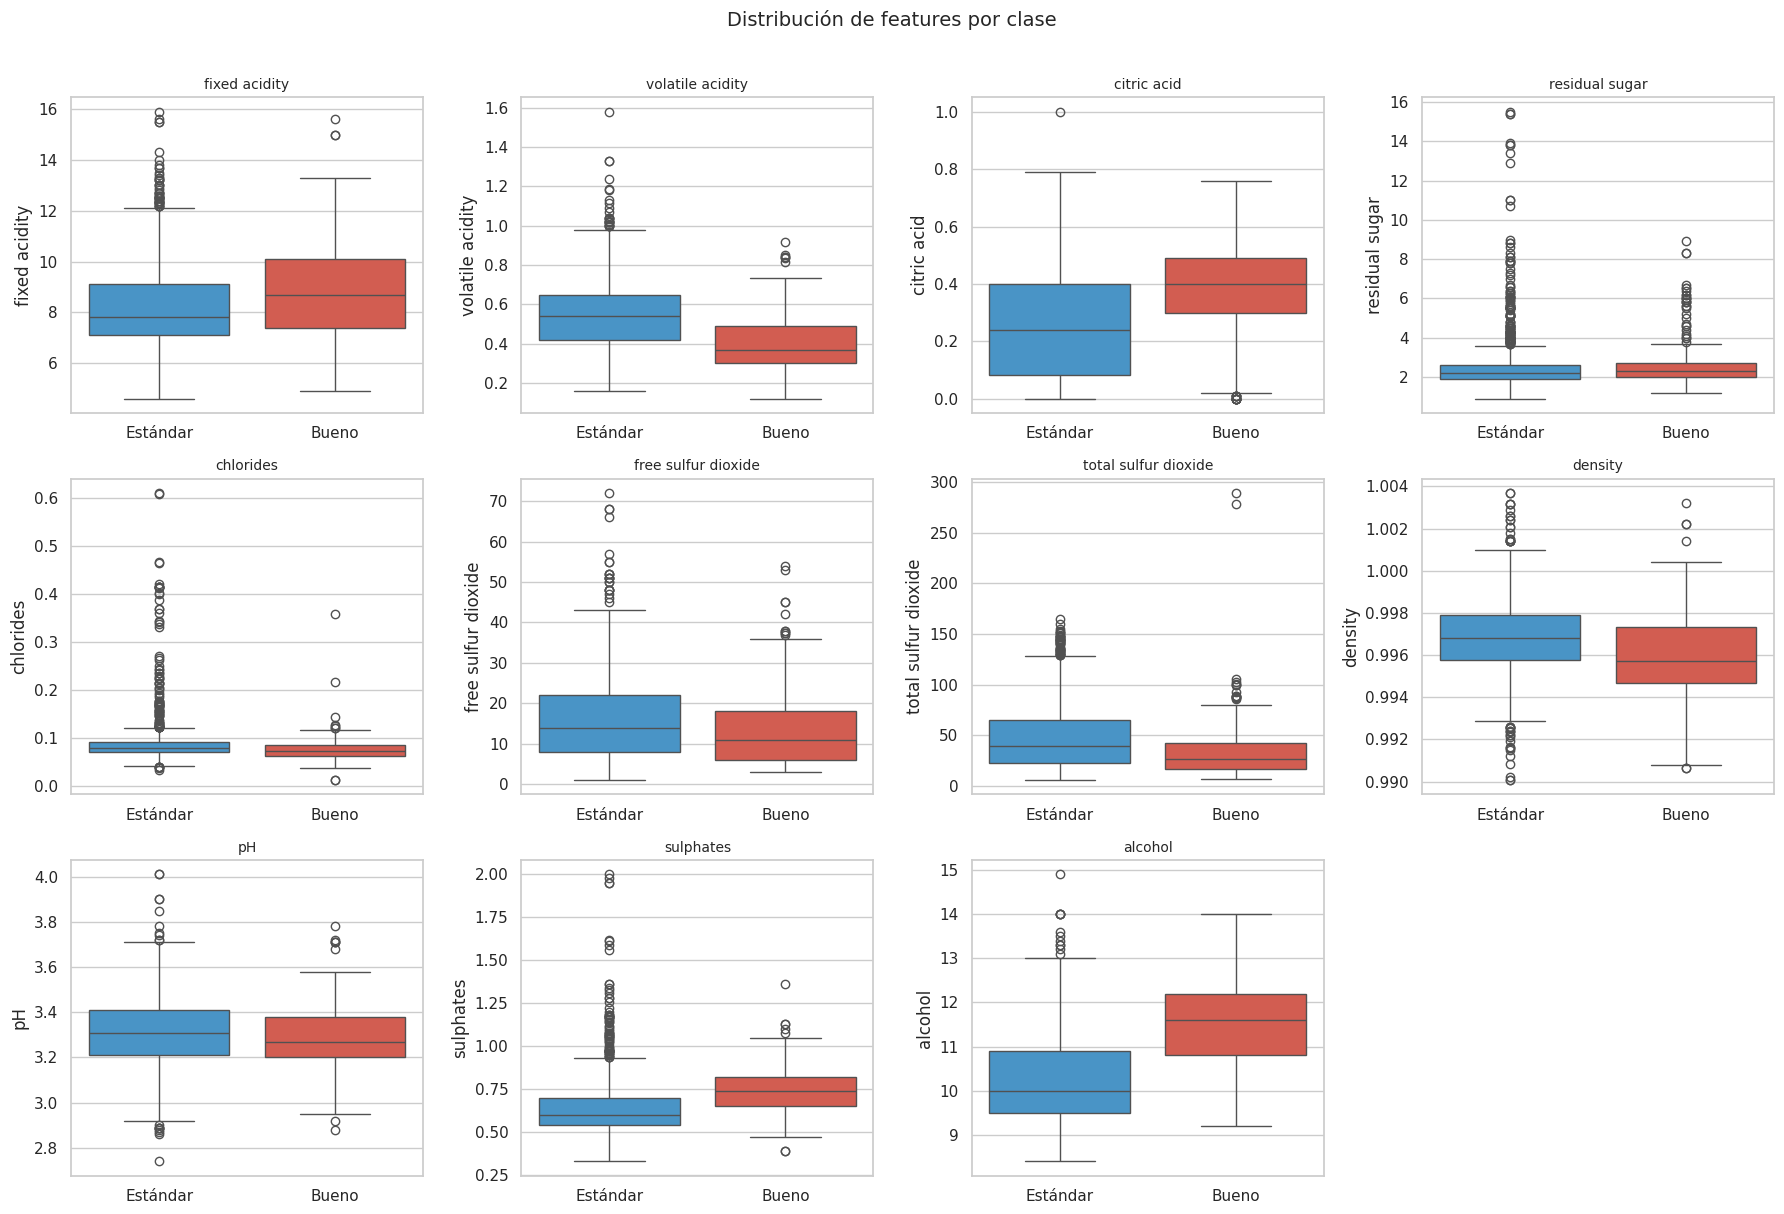

In [ ]:
# 3.2  Distribución de features por clase (boxplots)
fig, axes = plt.subplots(3, 4, figsize=(18, 12))
axes = axes.flatten()

for i, col in enumerate(features):
    sns.boxplot(data=df, x='quality_label', y=col, ax=axes[i],
                palette=['#3498db', '#e74c3c'], hue='quality_label', legend=False)
    axes[i].set_title(col, fontsize=10)
    axes[i].set_xlabel('')
    axes[i].set_xticklabels(['Estándar', 'Bueno'])

# Ocultar subplot vacío
axes[-1].set_visible(False)
fig.suptitle('Distribución de features por clase', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

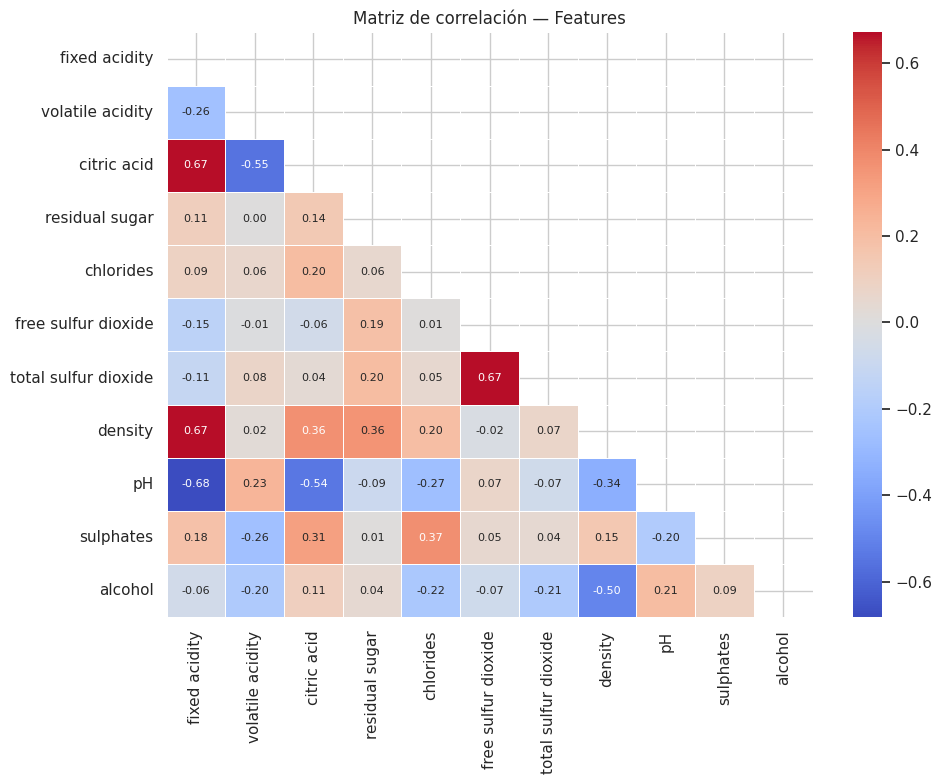

In [ ]:
# 3.3  Correlación entre features
plt.figure(figsize=(10, 8))
corr = df[features].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, annot_kws={'size': 8})
plt.title('Matriz de correlación — Features')
plt.tight_layout()
plt.show()

---
## 4. Preparación de datos

In [ ]:
# 4.1  Separación features / target
X = df[features].copy()
y = df['quality_label'].copy()

# 4.2  Split estratificado 80/20
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y
)

print(f'Train: {X_train.shape[0]} muestras  |  Test: {X_test.shape[0]} muestras')
print(f'Proporción clase 1 en train: {y_train.mean():.3f}')
print(f'Proporción clase 1 en test:  {y_test.mean():.3f}')

Train: 1279 muestras  |  Test: 320 muestras
Proporción clase 1 en train: 0.136
Proporción clase 1 en test:  0.134


In [ ]:
# 4.3  Verificación de escalas (justifica la estandarización)
print('Rangos de las features (train):')
print('='*50)
for col in features:
    mn, mx = X_train[col].min(), X_train[col].max()
    print(f'{col:30s}  [{mn:8.2f}, {mx:8.2f}]  rango: {mx-mn:.2f}')

print('\n→ Las escalas difieren significativamente entre features.')
print('  Esto afecta directamente a SVM y KNN (basados en distancias).')
print('  Logistic Regression también se beneficia de la estandarización.')

Rangos de las features (train):
fixed acidity                   [    4.60,    15.90]  rango: 11.30
volatile acidity                [    0.12,     1.58]  rango: 1.46
citric acid                     [    0.00,     1.00]  rango: 1.00
residual sugar                  [    0.90,    15.50]  rango: 14.60
chlorides                       [    0.01,     0.61]  rango: 0.60
free sulfur dioxide             [    1.00,    72.00]  rango: 71.00
total sulfur dioxide            [    6.00,   165.00]  rango: 159.00
density                         [    0.99,     1.00]  rango: 0.01
pH                              [    2.74,     4.01]  rango: 1.27
sulphates                       [    0.33,     2.00]  rango: 1.67
alcohol                         [    8.40,    14.90]  rango: 6.50

→ Las escalas difieren significativamente entre features.
  Esto afecta directamente a SVM y KNN (basados en distancias).
  Logistic Regression también se beneficia de la estandarización.


---
## 5. Modelo 1 — Regresión Logística

**Fundamento:** Modelo lineal que estima la probabilidad de pertenencia a una clase mediante la función sigmoide. Ideal como **baseline** por su interpretabilidad y eficiencia.

In [ ]:
# 5.1  Pipeline con estandarización
pipe_lr = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(max_iter=1000, random_state=RANDOM_STATE,
                               class_weight='balanced'))  # Compensar desbalance
])

# Validación cruzada
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
scores_lr = cross_val_score(pipe_lr, X_train, y_train, cv=cv, scoring='f1')
print(f'Logistic Regression — F1 CV: {scores_lr.mean():.4f} ± {scores_lr.std():.4f}')

# Entrenamiento final
pipe_lr.fit(X_train, y_train)
y_pred_lr = pipe_lr.predict(X_test)

Logistic Regression — F1 CV: 0.5045 ± 0.0355


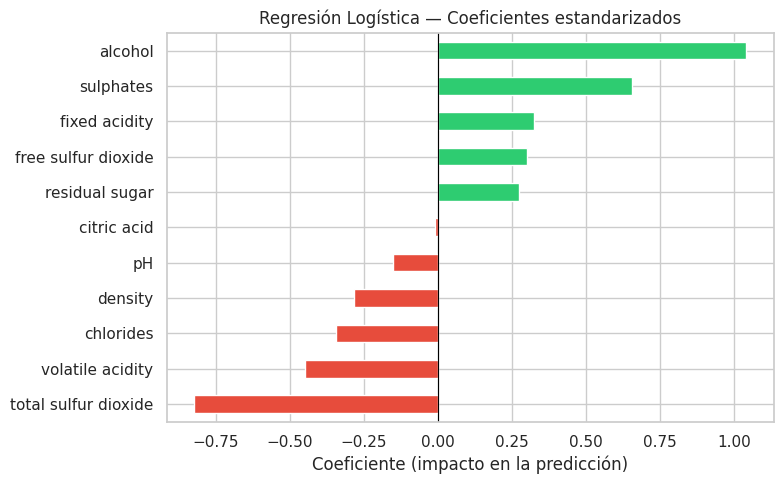


Interpretación: Un coeficiente positivo alto indica que valores mayores
de esa feature incrementan la probabilidad de clasificar como "Bueno".


In [ ]:
# 5.2  Coeficientes del modelo (interpretabilidad)
coefs = pd.Series(
    pipe_lr.named_steps['clf'].coef_[0],
    index=features
).sort_values()

fig, ax = plt.subplots(figsize=(8, 5))
colors = ['#e74c3c' if c < 0 else '#2ecc71' for c in coefs.values]
coefs.plot(kind='barh', ax=ax, color=colors)
ax.set_title('Regresión Logística — Coeficientes estandarizados')
ax.set_xlabel('Coeficiente (impacto en la predicción)')
ax.axvline(x=0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()

print('\nInterpretación: Un coeficiente positivo alto indica que valores mayores')
print('de esa feature incrementan la probabilidad de clasificar como "Bueno".')

---
## 6. Modelo 2 — Árbol de Decisión

**Fundamento:** Modelo no lineal que particiona el espacio de features mediante reglas if-else jerárquicas. Altamente interpretable, pero propenso al sobreajuste si no se controla la profundidad.

In [ ]:
# 6.1  Pipeline (no requiere estandarización)
pipe_dt = Pipeline([
    ('clf', DecisionTreeClassifier(
        max_depth=5, min_samples_leaf=10,
        class_weight='balanced', random_state=RANDOM_STATE
    ))
])

scores_dt = cross_val_score(pipe_dt, X_train, y_train, cv=cv, scoring='f1')
print(f'Decision Tree — F1 CV: {scores_dt.mean():.4f} ± {scores_dt.std():.4f}')

pipe_dt.fit(X_train, y_train)
y_pred_dt = pipe_dt.predict(X_test)

Decision Tree — F1 CV: 0.5126 ± 0.0331


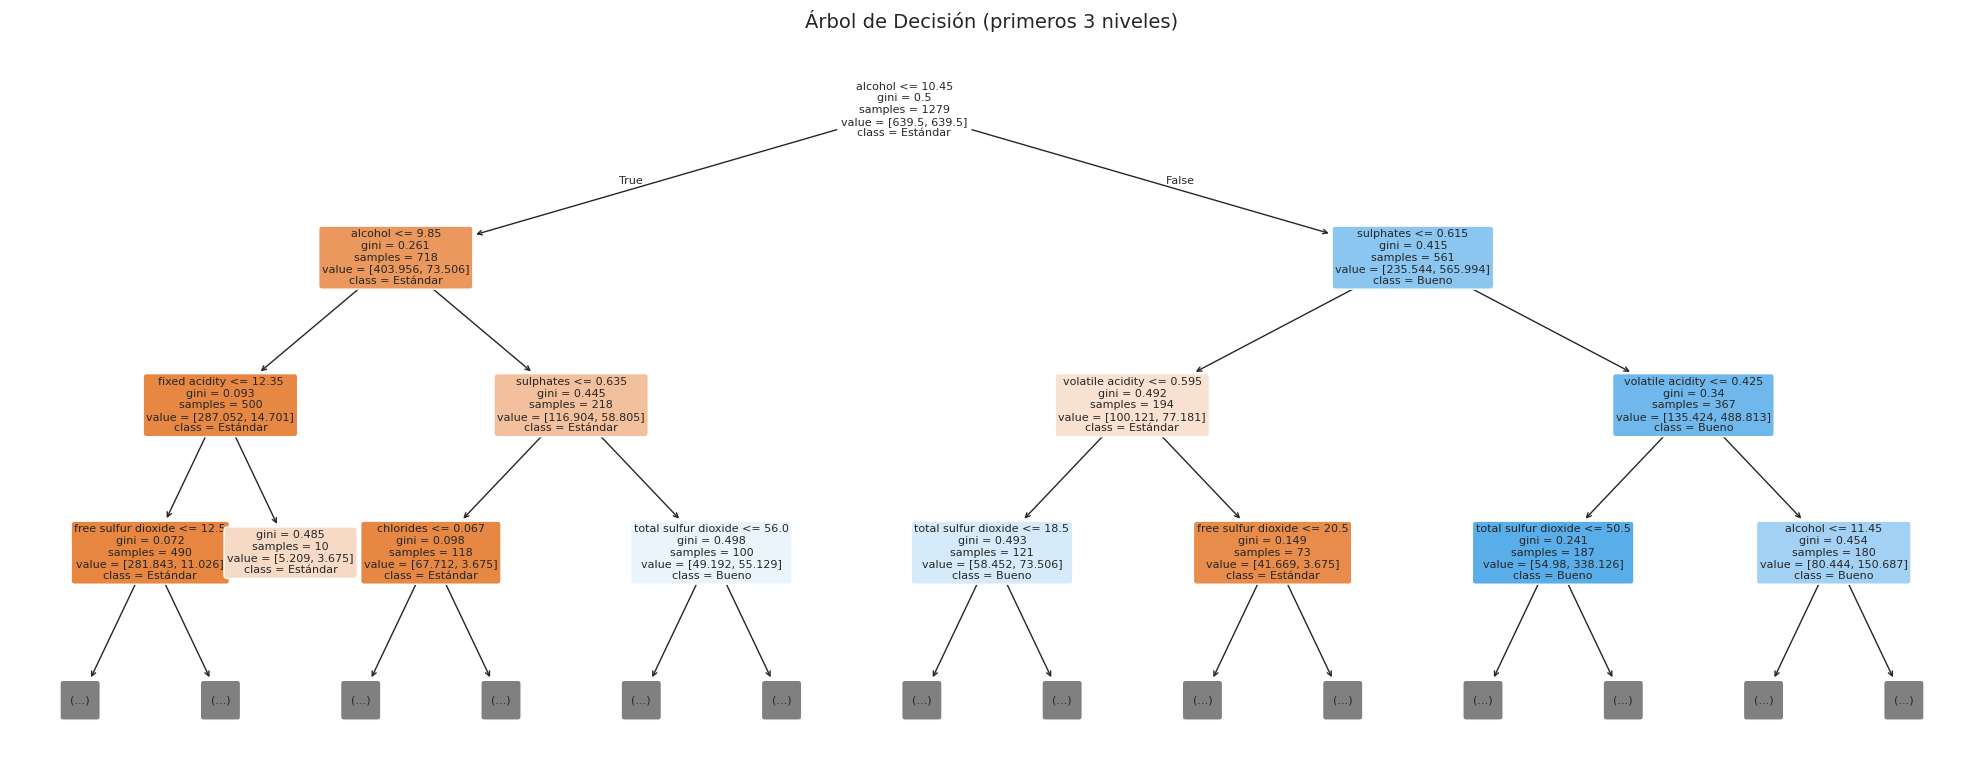

In [ ]:
# 6.2  Visualización del árbol
fig, ax = plt.subplots(figsize=(20, 8))
plot_tree(
    pipe_dt.named_steps['clf'],
    feature_names=list(features),
    class_names=['Estándar', 'Bueno'],
    filled=True, rounded=True, fontsize=8, ax=ax,
    max_depth=3  # Mostrar solo 3 niveles para legibilidad
)
ax.set_title('Árbol de Decisión (primeros 3 niveles)', fontsize=14)
plt.tight_layout()
plt.show()

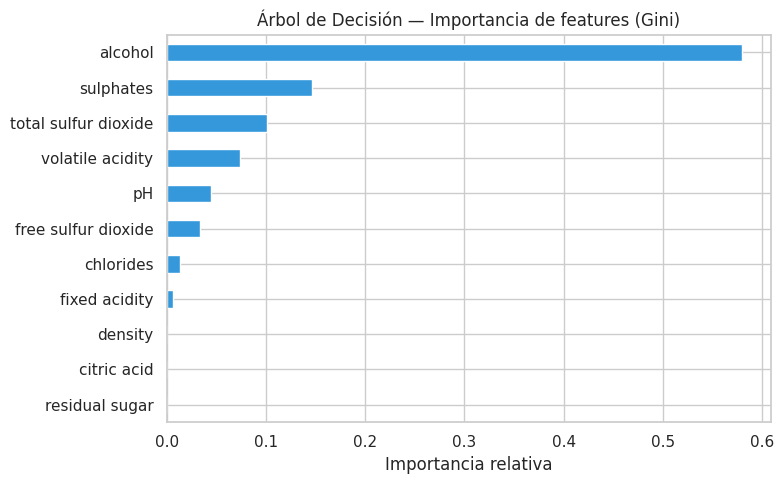

In [ ]:
# 6.3  Importancia de features (Gini importance)
importances = pd.Series(
    pipe_dt.named_steps['clf'].feature_importances_,
    index=features
).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 5))
importances.plot(kind='barh', ax=ax, color='#3498db')
ax.set_title('Árbol de Decisión — Importancia de features (Gini)')
ax.set_xlabel('Importancia relativa')
plt.tight_layout()
plt.show()

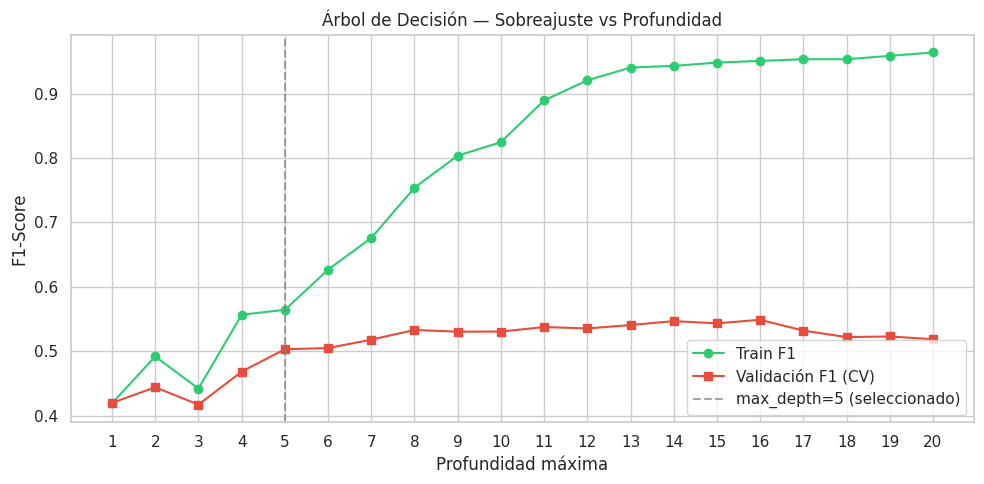

Observación: cuando la brecha entre train y validación crece,
el modelo está sobreajustando (memorizando el train set).


In [ ]:
# 6.4  Efecto de la profundidad en sobreajuste/subajuste
depths = range(1, 21)
train_scores = []
val_scores = []

for d in depths:
    dt = DecisionTreeClassifier(max_depth=d, class_weight='balanced',
                                 random_state=RANDOM_STATE)
    dt.fit(X_train, y_train)
    train_scores.append(f1_score(y_train, dt.predict(X_train)))
    cv_s = cross_val_score(dt, X_train, y_train, cv=cv, scoring='f1')
    val_scores.append(cv_s.mean())

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(depths, train_scores, 'o-', label='Train F1', color='#2ecc71')
ax.plot(depths, val_scores, 's-', label='Validación F1 (CV)', color='#e74c3c')
ax.axvline(x=5, color='gray', linestyle='--', alpha=0.7, label='max_depth=5 (seleccionado)')
ax.set_xlabel('Profundidad máxima')
ax.set_ylabel('F1-Score')
ax.set_title('Árbol de Decisión — Sobreajuste vs Profundidad')
ax.legend()
ax.set_xticks(depths)
plt.tight_layout()
plt.show()

print('Observación: cuando la brecha entre train y validación crece,')
print('el modelo está sobreajustando (memorizando el train set).')

---
## 7. Modelo 3 — Support Vector Machine (SVM)

**Fundamento:** Busca el hiperplano que maximiza el margen de separación entre clases. Con funciones kernel puede manejar fronteras no lineales. Es **sensible a la escala** de las features.

In [ ]:
# 7.1  Comparación de kernels
kernels = ['linear', 'rbf', 'poly']
svm_results = {}

for kernel in kernels:
    pipe_svm = Pipeline([
        ('scaler', StandardScaler()),
        ('clf', SVC(kernel=kernel, class_weight='balanced',
                     random_state=RANDOM_STATE, probability=True))
    ])
    scores = cross_val_score(pipe_svm, X_train, y_train, cv=cv, scoring='f1')
    svm_results[kernel] = scores
    print(f'SVM ({kernel:6s}) — F1 CV: {scores.mean():.4f} ± {scores.std():.4f}')

# Seleccionar el mejor kernel
best_kernel = max(svm_results, key=lambda k: svm_results[k].mean())
print(f'\nMejor kernel: {best_kernel}')

SVM (linear) — F1 CV: 0.4982 ± 0.0237
SVM (rbf   ) — F1 CV: 0.5246 ± 0.0427
SVM (poly  ) — F1 CV: 0.5355 ± 0.0258

Mejor kernel: poly


In [ ]:
# 7.2  Entrenamiento con el mejor kernel
pipe_svm = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', SVC(kernel=best_kernel, class_weight='balanced',
                 random_state=RANDOM_STATE, probability=True))
])

pipe_svm.fit(X_train, y_train)
y_pred_svm = pipe_svm.predict(X_test)
scores_svm = svm_results[best_kernel]

In [ ]:
# 7.3  Impacto de la estandarización en SVM
# SVM SIN estandarizar
svm_no_scale = SVC(kernel=best_kernel, class_weight='balanced',
                    random_state=RANDOM_STATE)
scores_no_scale = cross_val_score(svm_no_scale, X_train, y_train, cv=cv, scoring='f1')

print('Impacto de la estandarización en SVM:')
print(f'  CON StandardScaler: F1 = {scores_svm.mean():.4f}')
print(f'  SIN StandardScaler: F1 = {scores_no_scale.mean():.4f}')
print(f'  Diferencia: {(scores_svm.mean() - scores_no_scale.mean())*100:+.2f} puntos porcentuales')
print('\n→ La estandarización es CRÍTICA para modelos basados en distancias.')

Impacto de la estandarización en SVM:
  CON StandardScaler: F1 = 0.5355
  SIN StandardScaler: F1 = 0.2832
  Diferencia: +25.23 puntos porcentuales

→ La estandarización es CRÍTICA para modelos basados en distancias.


---
## 8. Modelo 4 — K-Nearest Neighbors (KNN)

**Fundamento:** Clasifica según la mayoría de votos de los K vecinos más cercanos. No paramétrico, sensible a la escala y a la dimensionalidad. El valor de K controla el trade-off bias-varianza.

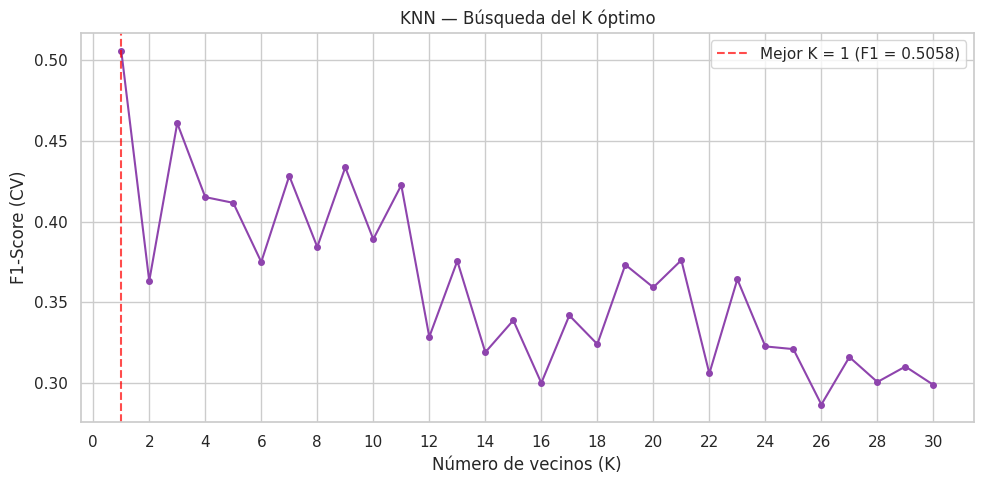

K óptimo: 1


In [ ]:
# 8.1  Búsqueda del K óptimo
k_range = range(1, 31)
k_scores = []

for k in k_range:
    pipe_knn = Pipeline([
        ('scaler', StandardScaler()),
        ('clf', KNeighborsClassifier(n_neighbors=k))
    ])
    scores = cross_val_score(pipe_knn, X_train, y_train, cv=cv, scoring='f1')
    k_scores.append(scores.mean())

best_k = k_range[np.argmax(k_scores)]

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(k_range, k_scores, 'o-', markersize=4, color='#8e44ad')
ax.axvline(x=best_k, color='red', linestyle='--', alpha=0.7,
           label=f'Mejor K = {best_k} (F1 = {max(k_scores):.4f})')
ax.set_xlabel('Número de vecinos (K)')
ax.set_ylabel('F1-Score (CV)')
ax.set_title('KNN — Búsqueda del K óptimo')
ax.legend()
ax.set_xticks(range(0, 31, 2))
plt.tight_layout()
plt.show()

print(f'K óptimo: {best_k}')

In [ ]:
# 8.2  Entrenamiento con K óptimo
pipe_knn = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', KNeighborsClassifier(n_neighbors=best_k))
])

scores_knn = cross_val_score(pipe_knn, X_train, y_train, cv=cv, scoring='f1')
print(f'KNN (K={best_k}) — F1 CV: {scores_knn.mean():.4f} ± {scores_knn.std():.4f}')

pipe_knn.fit(X_train, y_train)
y_pred_knn = pipe_knn.predict(X_test)

KNN (K=1) — F1 CV: 0.5058 ± 0.0254


---
## 9. Análisis comparativo de modelos

In [ ]:
# 9.1  Tabla resumen
models = {
    'Logistic Regression': (pipe_lr, y_pred_lr, scores_lr),
    'Decision Tree':       (pipe_dt, y_pred_dt, scores_dt),
    f'SVM ({best_kernel})': (pipe_svm, y_pred_svm, scores_svm),
    f'KNN (K={best_k})':   (pipe_knn, y_pred_knn, scores_knn)
}

summary = []
for name, (pipe, y_pred, cv_scores) in models.items():
    summary.append({
        'Modelo': name,
        'F1 CV (mean)': f'{cv_scores.mean():.4f}',
        'F1 CV (std)': f'{cv_scores.std():.4f}',
        'Accuracy Test': f'{accuracy_score(y_test, y_pred):.4f}',
        'F1 Test': f'{f1_score(y_test, y_pred):.4f}'
    })

summary_df = pd.DataFrame(summary)
print('='*80)
print('COMPARACIÓN DE MODELOS')
print('='*80)
summary_df

COMPARACIÓN DE MODELOS


,Modelo,F1 CV (mean),F1 CV (std),Accuracy Test,F1 Test
0,Logistic Regression,0.5045,0.0355,0.8125,0.5312
1,Decision Tree,0.5126,0.0331,0.8094,0.5414
2,SVM (poly),0.5355,0.0258,0.8969,0.6598
3,KNN (K=1),0.5058,0.0254,0.9094,0.6588


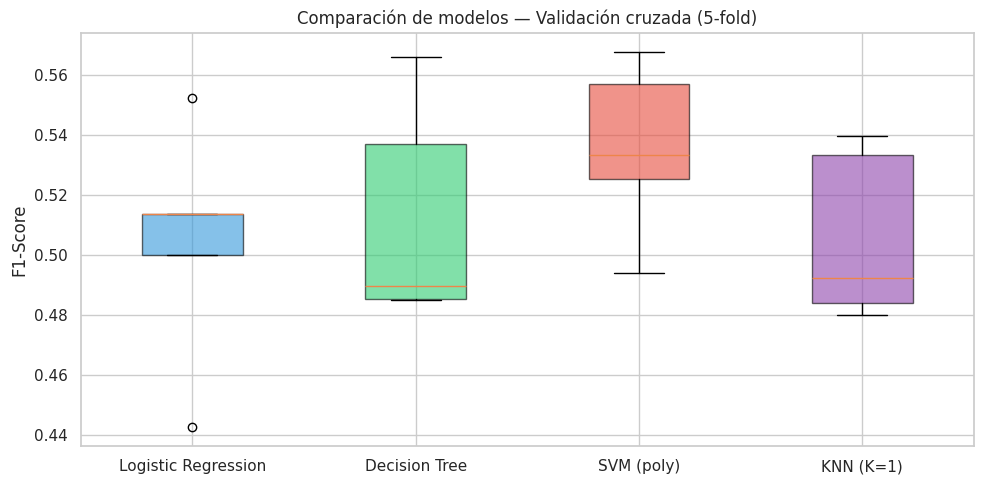

In [ ]:
# 9.2  Boxplot comparativo de validación cruzada
fig, ax = plt.subplots(figsize=(10, 5))
cv_data = [scores_lr, scores_dt, scores_svm, scores_knn]
labels = list(models.keys())
bp = ax.boxplot(cv_data, tick_labels=labels, patch_artist=True)
colors_box = ['#3498db', '#2ecc71', '#e74c3c', '#8e44ad']
for patch, color in zip(bp['boxes'], colors_box):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)
ax.set_ylabel('F1-Score')
ax.set_title('Comparación de modelos — Validación cruzada (5-fold)')
plt.tight_layout()
plt.show()

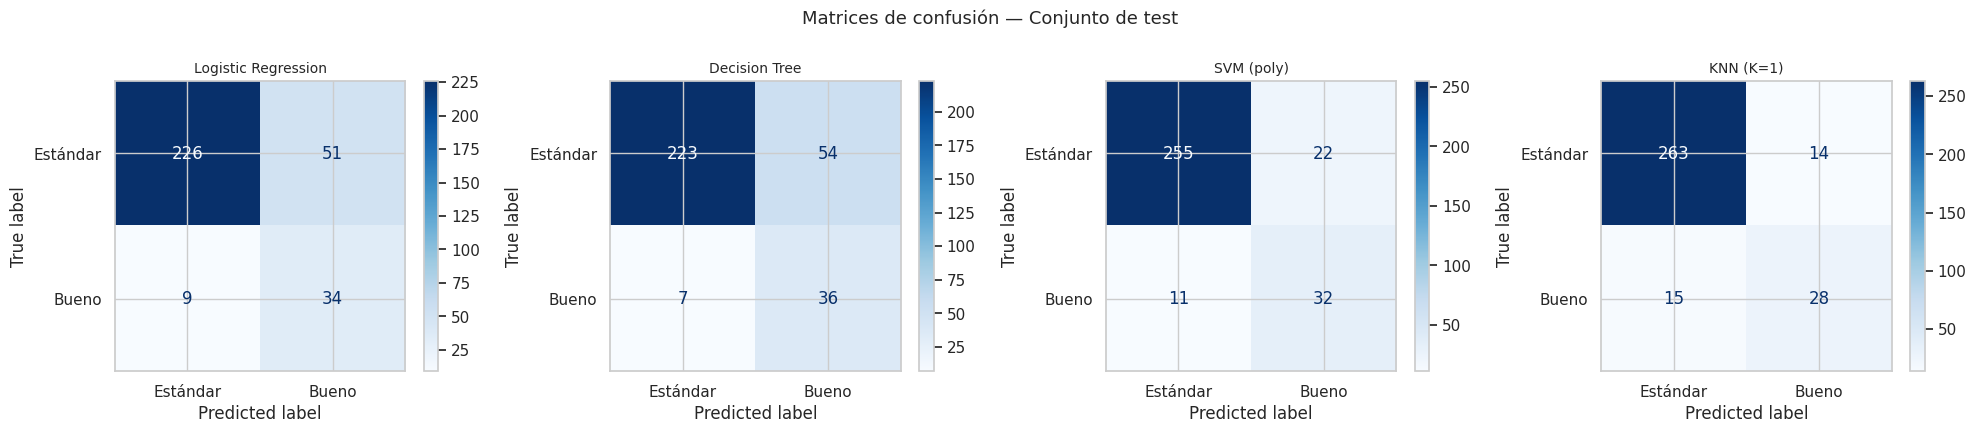

In [ ]:
# 9.3  Matrices de confusión comparativas
fig, axes = plt.subplots(1, 4, figsize=(20, 4))

for ax, (name, (pipe, y_pred, _)) in zip(axes, models.items()):
    ConfusionMatrixDisplay.from_predictions(
        y_test, y_pred,
        display_labels=['Estándar', 'Bueno'],
        cmap='Blues', ax=ax
    )
    ax.set_title(name, fontsize=10)

fig.suptitle('Matrices de confusión — Conjunto de test', fontsize=13, y=1.03)
plt.tight_layout()
plt.show()

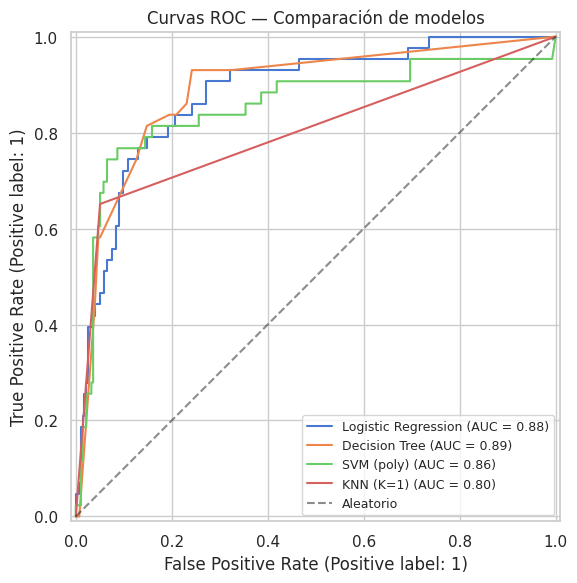

In [ ]:
# 9.4  Curvas ROC comparativas
fig, ax = plt.subplots(figsize=(7, 6))

for name, (pipe, _, _) in models.items():
    RocCurveDisplay.from_estimator(pipe, X_test, y_test, ax=ax, name=name)

ax.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Aleatorio')
ax.set_title('Curvas ROC — Comparación de modelos')
ax.legend(loc='lower right', fontsize=9)
plt.tight_layout()
plt.show()

In [ ]:
# 9.5  Classification report detallado del mejor modelo
best_model_name = max(models, key=lambda k: float(models[k][2].mean()))
best_pipe, best_pred, best_cv = models[best_model_name]

print(f'\nMejor modelo: {best_model_name}')
print('='*60)
print(classification_report(y_test, best_pred,
                             target_names=['Estándar', 'Bueno']))


Mejor modelo: SVM (poly)
              precision    recall  f1-score   support

    Estándar       0.96      0.92      0.94       277
       Bueno       0.59      0.74      0.66        43

    accuracy                           0.90       320
   macro avg       0.78      0.83      0.80       320
weighted avg       0.91      0.90      0.90       320



---
## 10. Resumen comparativo

| Modelo | Fortalezas | Limitaciones | ¿Cuándo usarlo? |
|---|---|---|---|
| **Regresión Logística** | Rápido, interpretable (coeficientes), probabilístico | Asume relación lineal entre features y log-odds | Baseline; cuando la interpretabilidad es prioritaria |
| **Árbol de Decisión** | Interpretable (visualización), maneja no linealidades, no requiere estandarización | Propenso a sobreajuste; inestable (pequeños cambios en datos alteran el árbol) | Cuando se necesitan reglas explicables; como parte de ensambles |
| **SVM** | Efectivo en alta dimensionalidad; flexible con kernels | Sensible a la escala; costoso en datasets grandes; difícil de interpretar | Datasets de tamaño moderado con fronteras complejas |
| **KNN** | Simple, no paramétrico, adaptable | Lento en predicción (distancias contra todo el train); sensible a escala y dimensionalidad | Datasets pequeños-medianos; cuando la frontera es irregular |

---
## 11. Ejercicios propuestos

### Ejercicio 1 — GridSearchCV para SVM
Realice una búsqueda de hiperparámetros para SVM usando `GridSearchCV` con la siguiente grilla:
- `C`: [0.1, 1, 10, 100]
- `gamma`: ['scale', 'auto', 0.01, 0.1]
- `kernel`: ['rbf', 'poly']

Reporte los mejores hiperparámetros, el F1-score obtenido y compare contra el SVM base de la sesión.

### Ejercicio 2 — Clasificación multiclase
En lugar de binarizar la variable `quality`, utilice las clases originales (3–8) y entrene los 4 modelos. Analice:
- ¿Cómo cambia el rendimiento de cada modelo?
- ¿Qué clases son más difíciles de distinguir?
- ¿Qué métrica de F1 es más adecuada: `macro`, `micro` o `weighted`? Justifique.

### Ejercicio 3 — Aplicación con dataset propio
Seleccione un dataset de clasificación de su interés (puede ser de Kaggle, UCI, o datos propios). Debe tener al menos 500 registros y 5 features. Aplique los 4 modelos de clasificación, realice el análisis comparativo completo y documente sus hallazgos.

---
## Ejercicio 1 — Solución: GridSearchCV para SVM

Se busca la mejor combinación de hiperparámetros para el SVM con `GridSearchCV`, usando la grilla del enunciado:
- `C`: [0.1, 1, 10, 100]
- `gamma`: ['scale', 'auto', 0.01, 0.1]
- `kernel`: ['rbf', 'poly']

Se mantiene el mismo esquema de la sesión: `Pipeline` con `StandardScaler`, `class_weight='balanced'`, la misma validación cruzada estratificada (`cv`, 5 folds) y **F1** como métrica. Como el objeto es un `Pipeline`, los hiperparámetros del SVM se indican con el prefijo `clf__`.

> **Nota:** son 32 combinaciones × 5 folds = 160 ajustes; puede tardar un par de minutos (sobre todo con `kernel='poly'` y `C` alto).

In [ ]:
# E1.1  Búsqueda de hiperparámetros con GridSearchCV
pipe_svm_gs = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', SVC(class_weight='balanced', random_state=RANDOM_STATE))
])

param_grid = {
    'clf__C':      [0.1, 1, 10, 100],
    'clf__gamma':  ['scale', 'auto', 0.01, 0.1],
    'clf__kernel': ['rbf', 'poly']
}

grid_svm = GridSearchCV(
    pipe_svm_gs, param_grid,
    cv=cv, scoring='f1', n_jobs=-1, refit=True
)
grid_svm.fit(X_train, y_train)

print('Mejores hiperparámetros:')
for param, valor in grid_svm.best_params_.items():
    print(f'  {param.replace("clf__", ""):8s} = {valor}')
print(f'\nMejor F1 (CV): {grid_svm.best_score_:.4f}')

In [ ]:
# E1.2  Top 5 combinaciones de la grilla
res_grid = pd.DataFrame(grid_svm.cv_results_)
top5 = (res_grid
        .sort_values('rank_test_score')
        .loc[:, ['param_clf__kernel', 'param_clf__C', 'param_clf__gamma',
                 'mean_test_score', 'std_test_score', 'rank_test_score']]
        .head(5)
        .rename(columns={'param_clf__kernel': 'kernel', 'param_clf__C': 'C',
                         'param_clf__gamma': 'gamma', 'mean_test_score': 'F1 CV (mean)',
                         'std_test_score': 'F1 CV (std)', 'rank_test_score': 'Ranking'})
        .reset_index(drop=True))
top5

In [ ]:
# E1.3  Comparación contra el SVM base de la sesión
best_svm_gs = grid_svm.best_estimator_
y_pred_gs = best_svm_gs.predict(X_test)

# SVM base = pipe_svm (kernel elegido en 7.1, C=1, gamma='scale')
comp_svm = pd.DataFrame({
    'Modelo': [f'SVM base ({best_kernel}, C=1, gamma=scale)',
               f'SVM GridSearch ({grid_svm.best_params_["clf__kernel"]}, '
               f'C={grid_svm.best_params_["clf__C"]}, gamma={grid_svm.best_params_["clf__gamma"]})'],
    'F1 CV (mean)':  [scores_svm.mean(), grid_svm.best_score_],
    'Accuracy Test': [accuracy_score(y_test, y_pred_svm), accuracy_score(y_test, y_pred_gs)],
    'F1 Test':       [f1_score(y_test, y_pred_svm), f1_score(y_test, y_pred_gs)]
}).round(4)

print('='*80)
print('SVM BASE vs SVM CON GRIDSEARCHCV')
print('='*80)
display(comp_svm)

d_cv = (grid_svm.best_score_ - scores_svm.mean()) * 100
d_test = (f1_score(y_test, y_pred_gs) - f1_score(y_test, y_pred_svm)) * 100
print(f'\nDiferencia en F1 CV:   {d_cv:+.2f} puntos porcentuales')
print(f'Diferencia en F1 Test: {d_test:+.2f} puntos porcentuales')
print('\nNota: el F1 CV del GridSearch está sesgado al alza (la misma CV se usó para')
print('elegir la combinación); la comparación más justa es la del F1 en Test.')

**Análisis.** La comparación relevante es la del **F1 en el conjunto de test**, porque el mejor F1 de CV del `GridSearchCV` es un valor *optimista*: se obtiene como el máximo entre 32 combinaciones evaluadas con los mismos folds.

- Si el F1 de test del SVM optimizado supera al del SVM base, la búsqueda aporta una mejora real de generalización.
- Si la diferencia es pequeña (dentro de la desviación estándar de la CV), el SVM base ya estaba cerca del óptimo y el ajuste fino aporta poco.
- Los valores de `C` y `gamma` seleccionados indican cuánta flexibilidad necesita la frontera de decisión: `C` alto y `gamma` alto → frontera más compleja (riesgo de sobreajuste); valores bajos → frontera más suave.

---
## Ejercicio 2 — Solución: clasificación multiclase

En lugar de binarizar `quality`, se utilizan las **clases originales (3–8)** como variable objetivo y se entrenan los 4 modelos con la misma configuración de la sesión (mismas features, mismo split estratificado 80/20, misma validación cruzada estratificada y `class_weight='balanced'` donde aplica). Para SVM y KNN se reutilizan el kernel y el K elegidos en la sesión (`best_kernel`, `best_k`).

Como el problema ya no es binario, el F1 debe promediarse entre clases: se calculan las variantes **macro**, **micro** y **weighted**.

In [ ]:
# E2.1  Variable objetivo multiclase y split estratificado
y_mc = df['quality'].copy()
classes_mc = sorted(y_mc.unique())

X_train_mc, X_test_mc, y_train_mc, y_test_mc = train_test_split(
    X, y_mc, test_size=0.20, random_state=RANDOM_STATE, stratify=y_mc
)

dist_mc = pd.DataFrame({
    'Total': y_mc.value_counts().sort_index(),
    '% del total': (y_mc.value_counts(normalize=True).sort_index() * 100).round(1),
    'Train': y_train_mc.value_counts().sort_index(),
    'Test': y_test_mc.value_counts().sort_index()
})
dist_mc.index.name = 'quality'
print(f'Train: {X_train_mc.shape[0]} muestras  |  Test: {X_test_mc.shape[0]} muestras')
print('\nDistribución de las clases (nótese el fuerte desbalance en los extremos):')
dist_mc

In [ ]:
# E2.2  Entrenamiento de los 4 modelos en modo multiclase
pipes_mc = {
    'Logistic Regression': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', LogisticRegression(max_iter=2000, random_state=RANDOM_STATE,
                                   class_weight='balanced'))
    ]),
    'Decision Tree': Pipeline([
        ('clf', DecisionTreeClassifier(max_depth=5, min_samples_leaf=10,
                                       class_weight='balanced', random_state=RANDOM_STATE))
    ]),
    f'SVM ({best_kernel})': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', SVC(kernel=best_kernel, class_weight='balanced', random_state=RANDOM_STATE))
    ]),
    f'KNN (K={best_k})': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', KNeighborsClassifier(n_neighbors=best_k))
    ])
}

models_mc = {}
for name, pipe in pipes_mc.items():
    cv_f1 = cross_val_score(pipe, X_train_mc, y_train_mc, cv=cv, scoring='f1_macro')
    pipe.fit(X_train_mc, y_train_mc)
    models_mc[name] = (pipe, pipe.predict(X_test_mc), cv_f1)
    print(f'{name:22s} — F1 macro CV: {cv_f1.mean():.4f} ± {cv_f1.std():.4f}')

In [ ]:
# E2.3  Tabla comparativa con las tres variantes de F1
rows = []
for name, (pipe, y_pred, cv_f1) in models_mc.items():
    rows.append({
        'Modelo': name,
        'F1 macro CV': cv_f1.mean(),
        'Accuracy Test': accuracy_score(y_test_mc, y_pred),
        'F1 macro': f1_score(y_test_mc, y_pred, average='macro', zero_division=0),
        'F1 micro': f1_score(y_test_mc, y_pred, average='micro', zero_division=0),
        'F1 weighted': f1_score(y_test_mc, y_pred, average='weighted', zero_division=0)
    })
summary_mc = pd.DataFrame(rows).set_index('Modelo')

# Referencia: resultados de la clasificación binaria (sección 9.1)
ref_bin = summary_df.set_index('Modelo')[['Accuracy Test', 'F1 Test']].astype(float)
ref_bin.columns = ['Accuracy binario', 'F1 binario (clase Bueno)']
summary_mc = summary_mc.join(ref_bin).round(4)

print('='*95)
print('COMPARACIÓN MULTICLASE (test)  vs  REFERENCIA BINARIA')
print('='*95)
display(summary_mc)

best_mc = summary_mc['F1 macro'].idxmax()
print(f'\nMejor modelo multiclase (F1 macro en test): {best_mc}')
print('Nota: el F1 binario evalúa solo la clase "Bueno"; no es directamente comparable con el F1 multiclase.')
print('Lo que sí muestra el cambio es la caída de accuracy al pasar de 2 a 6 clases.')

In [ ]:
# E2.4  Matrices de confusión normalizadas por fila (recall por clase)
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

for ax, (name, (pipe, y_pred, _)) in zip(axes.flatten(), models_mc.items()):
    ConfusionMatrixDisplay.from_predictions(
        y_test_mc, y_pred, labels=classes_mc,
        normalize='true', values_format='.2f',
        cmap='Blues', ax=ax, colorbar=False
    )
    ax.set_title(name, fontsize=11)

fig.suptitle('Matrices de confusión multiclase (normalizadas por fila) — Test', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

In [ ]:
# E2.5  ¿Qué clases son más difíciles de distinguir?
f1_por_clase = pd.DataFrame({
    name: f1_score(y_test_mc, y_pred, labels=classes_mc, average=None, zero_division=0)
    for name, (pipe, y_pred, _) in models_mc.items()
}, index=classes_mc)
f1_por_clase.index.name = 'quality'
f1_por_clase['Soporte (test)'] = y_test_mc.value_counts().sort_index()

fig, ax = plt.subplots(figsize=(9, 4.5))
sns.heatmap(f1_por_clase.drop(columns='Soporte (test)'), annot=True, fmt='.2f',
            cmap='YlGnBu', vmin=0, vmax=1, linewidths=0.5, ax=ax)
ax.set_title('F1 por clase y modelo (test)')
ax.set_ylabel('Calidad (quality)')
plt.tight_layout()
plt.show()

print('Clase más difícil por modelo (menor F1) y soporte de la clase en test:')
for name in models_mc:
    peor = f1_por_clase[name].idxmin()
    print(f'  {name:22s} → quality={peor}  (F1={f1_por_clase.loc[peor, name]:.2f}, '
          f'n_test={int(f1_por_clase.loc[peor, "Soporte (test)"])})')

# Proporción de errores "cercanos" (a ±1 punto de calidad): indica confusión entre clases vecinas
print('\nDe los errores cometidos, % que se equivocan por solo ±1 punto de calidad:')
for name, (pipe, y_pred, _) in models_mc.items():
    err = (y_test_mc.values != y_pred)
    cerca = (np.abs(y_test_mc.values[err] - y_pred[err]) == 1).mean() * 100
    print(f'  {name:22s} → {cerca:.1f}%  ({err.sum()} errores)')

In [ ]:
# E2.6  Comparación de las variantes de F1 (por qué elegir una u otra)
mejor_pred = models_mc[best_mc][1]
print(f'Modelo: {best_mc}')
print(f'  Accuracy    = {accuracy_score(y_test_mc, mejor_pred):.4f}')
print(f'  F1 micro    = {f1_score(y_test_mc, mejor_pred, average="micro", zero_division=0):.4f}   (idéntico a la accuracy en multiclase de etiqueta única)')
print(f'  F1 weighted = {f1_score(y_test_mc, mejor_pred, average="weighted", zero_division=0):.4f}   (pondera por soporte → dominado por quality 5 y 6)')
print(f'  F1 macro    = {f1_score(y_test_mc, mejor_pred, average="macro", zero_division=0):.4f}   (todas las clases pesan igual → penaliza fallar en 3, 4 y 8)')
print()
print(classification_report(y_test_mc, mejor_pred, labels=classes_mc, zero_division=0))

**Análisis.**

**1. ¿Cómo cambia el rendimiento?** Al pasar de 2 a 6 clases el problema es mucho más exigente: la accuracy y el F1 caen respecto de la versión binaria (ver tabla E2.3), porque ya no basta con separar "bueno" de "no bueno", sino que hay que ubicar cada vino en su nivel exacto de calidad. El ranking entre modelos puede cambiar respecto del caso binario; la tabla E2.3 muestra qué modelo lidera en cada variante de F1.

**2. ¿Qué clases son más difíciles?** Se distinguen dos causas, que el código de E2.5 permite verificar:
- **Clases extremas y minoritarias** (`quality` 3, 4 y 8): tienen muy pocas muestras (la clase 3 tiene apenas 10 vinos en todo el dataset, es decir, ~2 en test), por lo que su F1 suele ser el más bajo y muy inestable.
- **Clases vecinas** (5 vs 6, y 6 vs 7): sus perfiles fisicoquímicos se solapan; la calidad es una escala **ordinal**, y la mayoría de los errores caen a ±1 punto (último bloque de E2.5), no en saltos grandes.

**3. ¿Qué F1 es más adecuado? → `macro`.**
- **`micro`** agrega todos los aciertos y errores: en multiclase de etiqueta única es **igual a la accuracy**, y queda dominado por las clases 5 y 6 (~80 % de los datos). Oculta el mal desempeño en las clases raras.
- **`weighted`** promedia los F1 por clase ponderando por su soporte; por lo tanto también está dominado por 5 y 6 y solo "suaviza" el problema del desbalance.
- **`macro`** promedia el F1 de cada clase con el mismo peso, de modo que fallar en `quality` 3, 4 u 8 penaliza igual que fallar en 5 o 6. Como el dataset está fuertemente desbalanceado y las clases extremas son justamente las de mayor interés (vinos muy malos o excelentes), **F1 macro es la métrica más honesta**. Conviene reportar `weighted` como complemento (para reflejar el rendimiento "promedio por vino") y el F1 por clase para el diagnóstico.

---
## Ejercicio 3 — Solución: aplicación con dataset propio

**Dataset seleccionado:** *Viral Social Media Trends* (5 000 publicaciones de TikTok, Instagram, Twitter y YouTube).  
Cumple los requisitos del ejercicio: **5 000 registros** (≥ 500) y **8 features** (≥ 5): 4 numéricas (`Views`, `Likes`, `Shares`, `Comments`) y 4 categóricas (`Platform`, `Hashtag`, `Content_Type`, `Region`). La columna `Post_ID` es solo un identificador y se descarta.

A continuación se replica **la misma estructura de 10 apartados** de la sesión, adaptada a este dataset.

### Ejercicio 3 · 1. Configuración del entorno

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import (
    train_test_split, cross_val_score, StratifiedKFold, GridSearchCV
)
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix,
    ConfusionMatrixDisplay, RocCurveDisplay,
    accuracy_score, f1_score
)

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['figure.dpi'] = 100

RANDOM_STATE = 42
print('Entorno configurado correctamente.')

Entorno configurado correctamente.


---
### Ejercicio 3 · 2. Carga y comprensión del dataset

Utilizamos el dataset **Viral Social Media Trends**, con 5 000 publicaciones y una variable objetivo `Engagement_Level` con tres niveles (*Low*, *Medium*, *High*).

Para mantener el **mismo planteamiento de clasificación binaria** de la sesión, definimos:
- **Clase 1 (Alto):** `Engagement_Level` = High
- **Clase 0 (No alto):** `Engagement_Level` = Low o Medium

Esta binarización genera un problema **desbalanceado (≈ 2:1)**, lo que mantiene el reto de trabajar con la clase de interés como minoritaria.

In [ ]:
# Carga del archivo (en Colab, si no está en el entorno, se solicita la subida)
CSV_PATH = 'Viral_Social_Media_Trends.csv'
if not os.path.exists(CSV_PATH):
    from google.colab import files
    print('Sube el archivo Viral_Social_Media_Trends.csv')
    files.upload()

df_v = pd.read_csv(CSV_PATH)
print(f'Dataset cargado: {df_v.shape[0]} registros, {df_v.shape[1]} columnas')
print(f'Valores nulos totales: {df_v.isna().sum().sum()}  |  Filas duplicadas: {df_v.drop(columns="Post_ID").duplicated().sum()}')
df_v.head()

Dataset cargado: 5000 registros, 10 columnas
Valores nulos totales: 0  |  Filas duplicadas: 0


,Post_ID,Platform,Hashtag,Content_Type,Region,Views,Likes,Shares,Comments,Engagement_Level
0,Post_1,TikTok,#Challenge,Video,UK,4163464,339431,53135,19346,High
1,Post_2,Instagram,#Education,Shorts,India,4155940,215240,65860,27239,Medium
2,Post_3,Twitter,#Challenge,Video,Brazil,3666211,327143,39423,36223,Medium
3,Post_4,YouTube,#Education,Shorts,Australia,917951,127125,11687,36806,Low
4,Post_5,TikTok,#Dance,Post,Brazil,64866,171361,69581,6376,Medium


Distribución del nivel de engagement original:
Engagement_Level
Low       1729
High      1673
Medium    1598
Name: count, dtype: int64


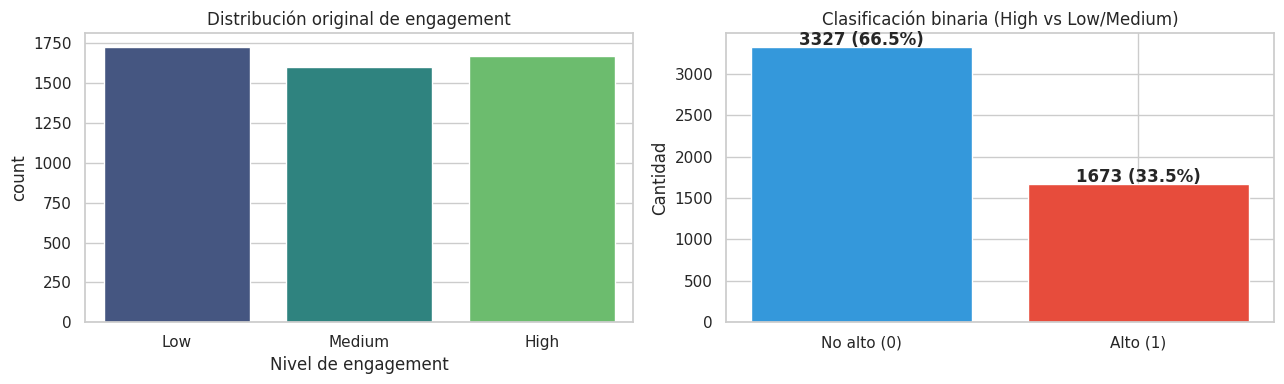


Ratio de desbalance: 2.0:1 (No alto vs Alto)


In [ ]:
# Distribución original de la variable 'Engagement_Level'
print('Distribución del nivel de engagement original:')
print(df_v['Engagement_Level'].value_counts())

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Histograma original
order = ['Low', 'Medium', 'High']
sns.countplot(data=df_v, x='Engagement_Level', order=order, ax=axes[0], palette='viridis')
axes[0].set_title('Distribución original de engagement')
axes[0].set_xlabel('Nivel de engagement')

# Binarización
df_v['engagement_label'] = (df_v['Engagement_Level'] == 'High').astype(int)

counts = df_v['engagement_label'].value_counts()
axes[1].bar(['No alto (0)', 'Alto (1)'], counts.values,
            color=['#3498db', '#e74c3c'])
for i, v in enumerate(counts.values):
    axes[1].text(i, v + 25, f'{v} ({v/len(df_v)*100:.1f}%)', ha='center', fontweight='bold')
axes[1].set_title('Clasificación binaria (High vs Low/Medium)')
axes[1].set_ylabel('Cantidad')

plt.tight_layout()
plt.show()

print(f'\nRatio de desbalance: {counts[0]/counts[1]:.1f}:1 (No alto vs Alto)')

---
### Ejercicio 3 · 3. Análisis exploratorio orientado a clasificación

In [ ]:
# 3.1  Estadísticas descriptivas por clase (features numéricas)
num_cols = ['Views', 'Likes', 'Shares', 'Comments']
cat_cols = ['Platform', 'Hashtag', 'Content_Type', 'Region']
features_v = num_cols + cat_cols

comparison_v = df_v.groupby('engagement_label')[num_cols].mean().T
comparison_v.columns = ['No alto (0)', 'Alto (1)']
comparison_v['Diferencia %'] = ((comparison_v['Alto (1)'] - comparison_v['No alto (0)']) / comparison_v['No alto (0)'] * 100).round(1)
comparison_v.style.background_gradient(subset=['Diferencia %'], cmap='RdYlGn')

,No alto (0),Alto (1),Diferencia %
Views,2517698.559663,2447070.598924,-2.800000
Likes,251770.464683,250887.515242,-0.400000
Shares,50186.782086,51181.342499,2.000000
Comments,25024.032462,24618.656904,-1.600000


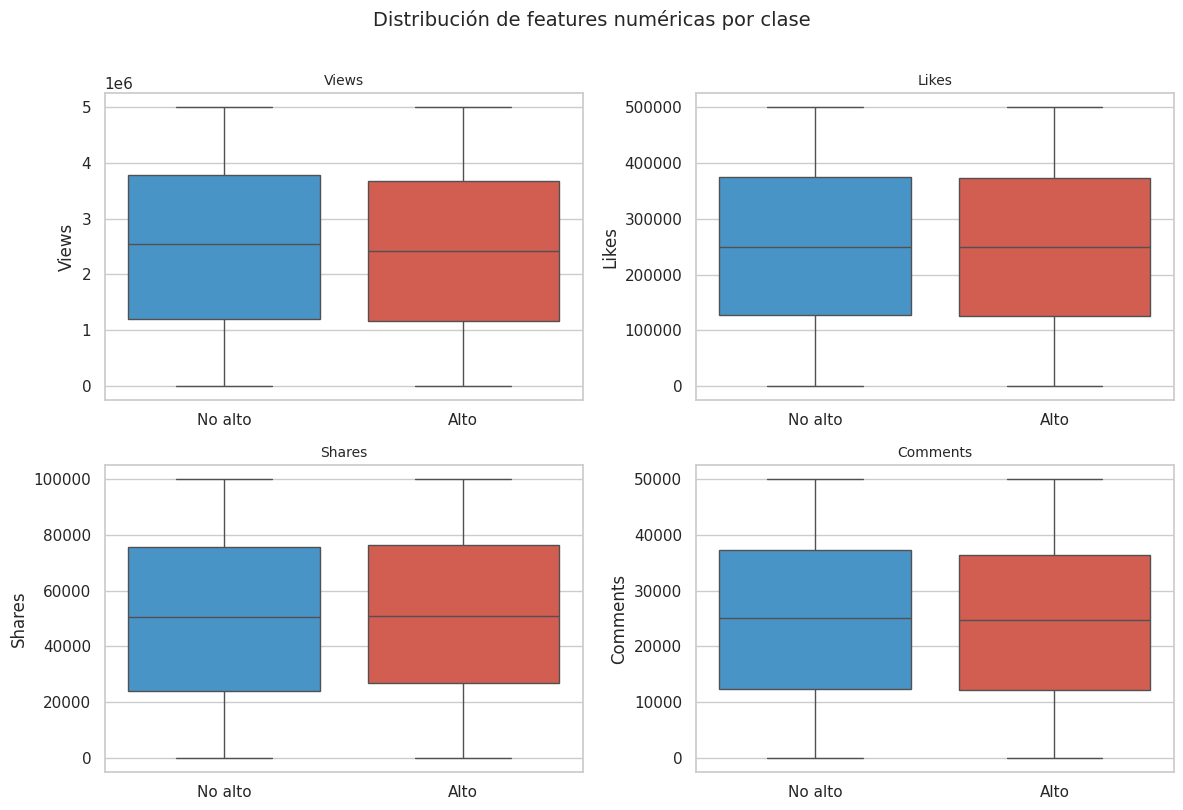

In [ ]:
# 3.2  Distribución de features por clase (boxplots)
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.boxplot(data=df_v, x='engagement_label', y=col, ax=axes[i],
                palette=['#3498db', '#e74c3c'], hue='engagement_label', legend=False)
    axes[i].set_title(col, fontsize=10)
    axes[i].set_xlabel('')
    axes[i].set_xticklabels(['No alto', 'Alto'])

fig.suptitle('Distribución de features numéricas por clase', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

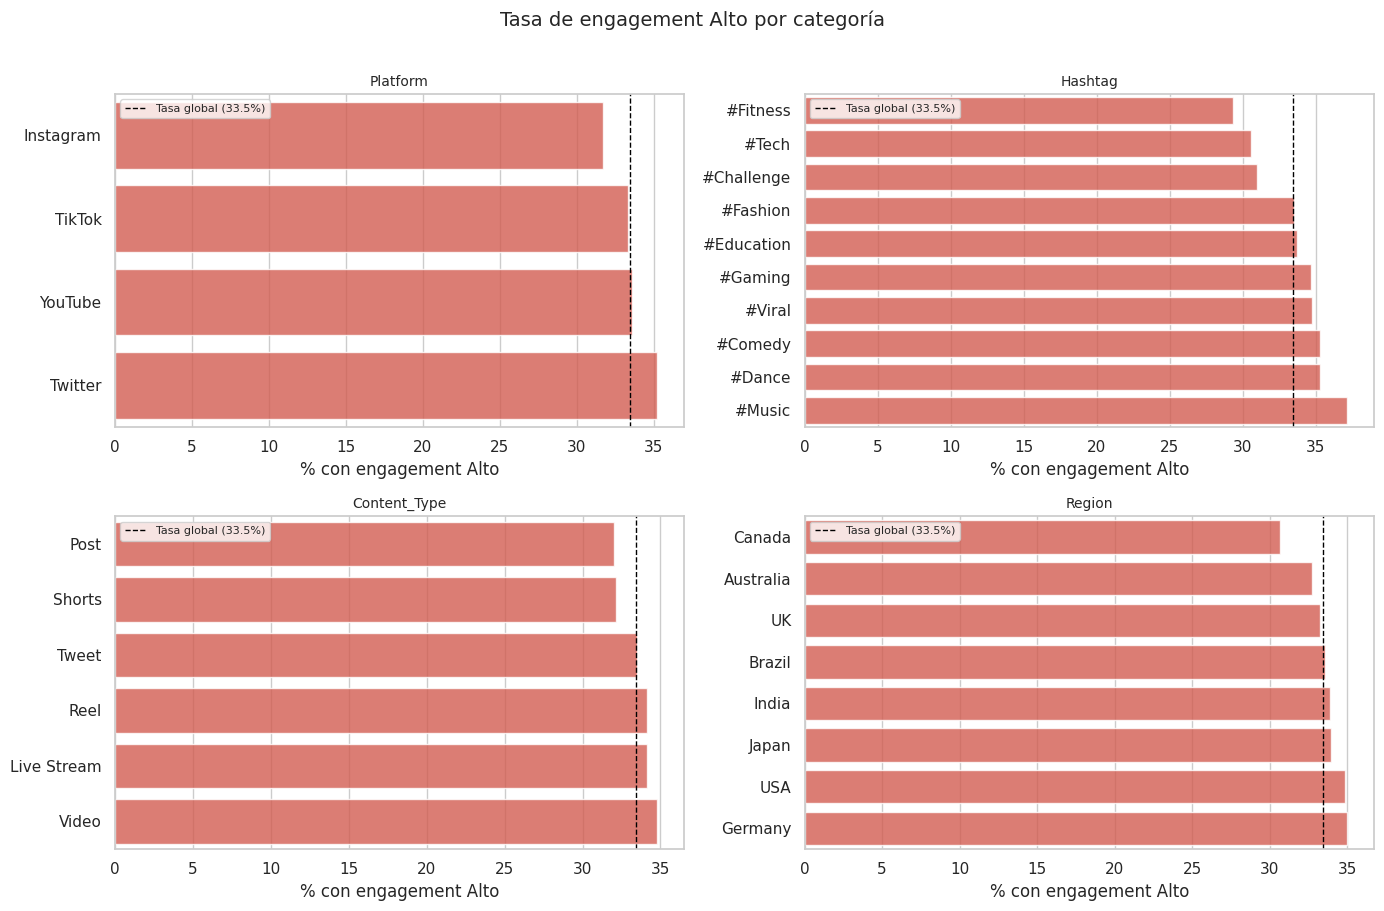

In [ ]:
# 3.2b  Features categóricas: % de publicaciones con engagement Alto por categoría
# (los boxplots no aplican a variables categóricas; se usa la tasa de clase 1)
base_rate = df_v['engagement_label'].mean() * 100

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    rate = (df_v.groupby(col)['engagement_label'].mean() * 100).sort_values()
    sns.barplot(x=rate.values, y=rate.index, ax=axes[i], color='#e74c3c', alpha=0.8)
    axes[i].axvline(base_rate, color='black', linestyle='--', linewidth=1,
                    label=f'Tasa global ({base_rate:.1f}%)')
    axes[i].set_title(col, fontsize=10)
    axes[i].set_xlabel('% con engagement Alto')
    axes[i].set_ylabel('')
    axes[i].legend(fontsize=8)

fig.suptitle('Tasa de engagement Alto por categoría', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

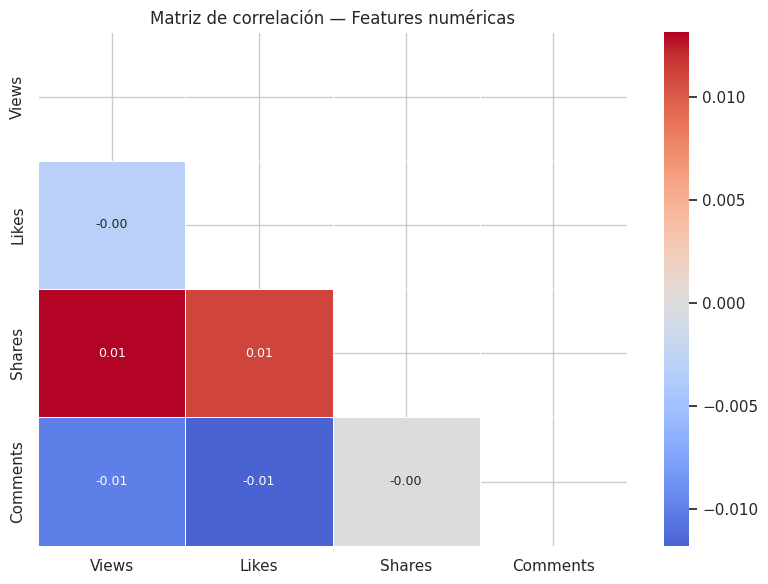

In [ ]:
# 3.3  Correlación entre features (numéricas)
plt.figure(figsize=(8, 6))
corr = df_v[num_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, annot_kws={'size': 9})
plt.title('Matriz de correlación — Features numéricas')
plt.tight_layout()
plt.show()

---
### Ejercicio 3 · 4. Preparación de datos

In [ ]:
# 4.1  Separación features / target
X_v = df_v[features_v].copy()
y_v = df_v['engagement_label'].copy()

# 4.2  Split estratificado 80/20
X_train_v, X_test_v, y_train_v, y_test_v = train_test_split(
    X_v, y_v, test_size=0.20, random_state=RANDOM_STATE, stratify=y_v
)

print(f'Train: {X_train_v.shape[0]} muestras  |  Test: {X_test_v.shape[0]} muestras')
print(f'Proporción clase 1 en train: {y_train_v.mean():.3f}')
print(f'Proporción clase 1 en test:  {y_test_v.mean():.3f}')

Train: 4000 muestras  |  Test: 1000 muestras
Proporción clase 1 en train: 0.335
Proporción clase 1 en test:  0.335


In [ ]:
# 4.3  Verificación de escalas (justifica la estandarización)
print('Rangos de las features numéricas (train):')
print('='*60)
for col in num_cols:
    mn, mx = X_train_v[col].min(), X_train_v[col].max()
    print(f'{col:30s}  [{mn:12.0f}, {mx:12.0f}]  rango: {mx-mn:.0f}')

print('\nFeatures categóricas (se codifican con One-Hot):')
for col in cat_cols:
    print(f'{col:30s}  {X_train_v[col].nunique()} categorías')

print('\n→ Las escalas difieren significativamente entre features (Views vs Comments).')
print('  Esto afecta directamente a SVM y KNN (basados en distancias).')
print('  Logistic Regression también se beneficia de la estandarización.')

Rangos de las features numéricas (train):
Views                           [        1266,      4999430]  rango: 4998164
Likes                           [         490,       499874]  rango: 499384
Shares                          [          52,        99978]  rango: 99926
Comments                        [          18,        49993]  rango: 49975

Features categóricas (se codifican con One-Hot):
Platform                        4 categorías
Hashtag                         10 categorías
Content_Type                    6 categorías
Region                          8 categorías

→ Las escalas difieren significativamente entre features (Views vs Comments).
  Esto afecta directamente a SVM y KNN (basados en distancias).
  Logistic Regression también se beneficia de la estandarización.


In [ ]:
# 4.4  Preprocesador: estandarización (numéricas) + One-Hot (categóricas)
def build_preprocessor(scale=True):
    num_tf = StandardScaler() if scale else 'passthrough'
    return ColumnTransformer([
        ('num', num_tf, num_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
    ])

prep_demo = build_preprocessor().fit(X_train_v)
feature_names_v = [n.split('__', 1)[1] for n in prep_demo.get_feature_names_out()]
print(f'Features tras el preprocesamiento: {len(feature_names_v)} '
      f'({len(num_cols)} numéricas + {len(feature_names_v) - len(num_cols)} columnas One-Hot)')

Features tras el preprocesamiento: 32 (4 numéricas + 28 columnas One-Hot)


---
### Ejercicio 3 · 5. Modelo 1 — Regresión Logística

**Fundamento:** Modelo lineal que estima la probabilidad de pertenencia a una clase mediante la función sigmoide. Ideal como **baseline** por su interpretabilidad y eficiencia.

In [ ]:
# 5.1  Pipeline con estandarización
pipe_lr_v = Pipeline([
    ('prep', build_preprocessor(scale=True)),
    ('clf', LogisticRegression(max_iter=1000, random_state=RANDOM_STATE,
                               class_weight='balanced'))  # Compensar desbalance
])

# Validación cruzada
cv_v = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
scores_lr_v = cross_val_score(pipe_lr_v, X_train_v, y_train_v, cv=cv_v, scoring='f1')
print(f'Logistic Regression — F1 CV: {scores_lr_v.mean():.4f} ± {scores_lr_v.std():.4f}')

# Entrenamiento final
pipe_lr_v.fit(X_train_v, y_train_v)
y_pred_lr_v = pipe_lr_v.predict(X_test_v)

Logistic Regression — F1 CV: 0.4013 ± 0.0282


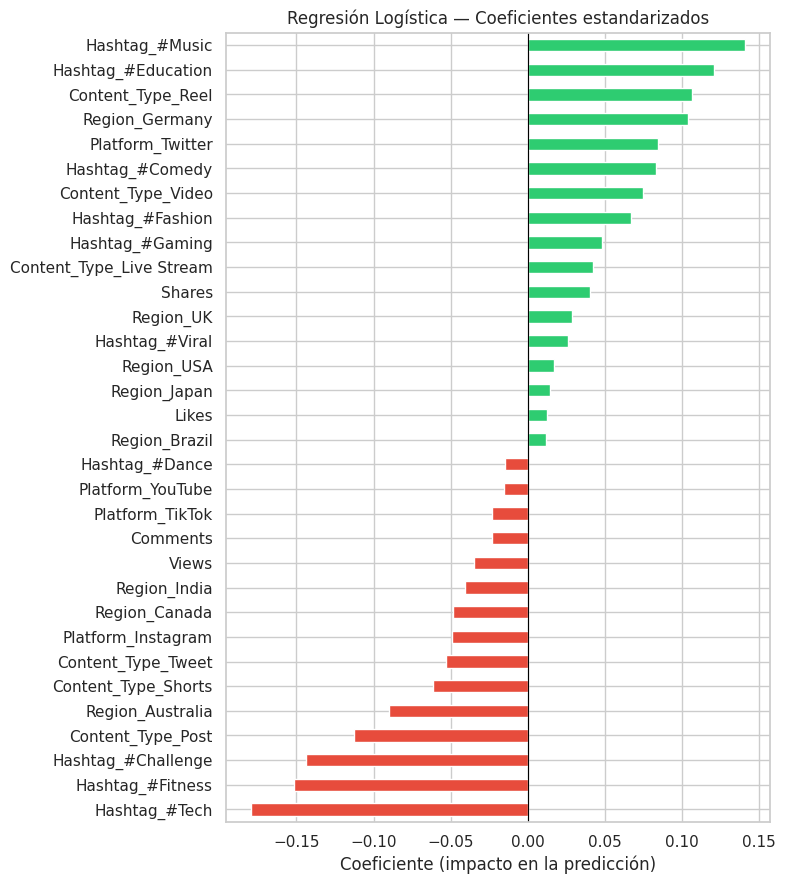


Interpretación: Un coeficiente positivo alto indica que valores mayores
de esa feature incrementan la probabilidad de clasificar como "Alto".
Coeficiente de mayor magnitud: |0.180| (Hashtag_#Tech)


In [ ]:
# 5.2  Coeficientes del modelo (interpretabilidad)
coefs_v = pd.Series(
    pipe_lr_v.named_steps['clf'].coef_[0],
    index=feature_names_v
).sort_values()

fig, ax = plt.subplots(figsize=(8, 9))
colors = ['#e74c3c' if c < 0 else '#2ecc71' for c in coefs_v.values]
coefs_v.plot(kind='barh', ax=ax, color=colors)
ax.set_title('Regresión Logística — Coeficientes estandarizados')
ax.set_xlabel('Coeficiente (impacto en la predicción)')
ax.axvline(x=0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()

print('\nInterpretación: Un coeficiente positivo alto indica que valores mayores')
print('de esa feature incrementan la probabilidad de clasificar como "Alto".')
print(f'Coeficiente de mayor magnitud: |{coefs_v.abs().max():.3f}| ({coefs_v.abs().idxmax()})')

---
### Ejercicio 3 · 6. Modelo 2 — Árbol de Decisión

**Fundamento:** Modelo no lineal que particiona el espacio de features mediante reglas if-else jerárquicas. Altamente interpretable, pero propenso al sobreajuste si no se controla la profundidad.

In [ ]:
# 6.1  Pipeline (no requiere estandarización; solo One-Hot de las categóricas)
pipe_dt_v = Pipeline([
    ('prep', build_preprocessor(scale=False)),
    ('clf', DecisionTreeClassifier(
        max_depth=5, min_samples_leaf=10,
        class_weight='balanced', random_state=RANDOM_STATE
    ))
])

scores_dt_v = cross_val_score(pipe_dt_v, X_train_v, y_train_v, cv=cv_v, scoring='f1')
print(f'Decision Tree — F1 CV: {scores_dt_v.mean():.4f} ± {scores_dt_v.std():.4f}')

pipe_dt_v.fit(X_train_v, y_train_v)
y_pred_dt_v = pipe_dt_v.predict(X_test_v)

Decision Tree — F1 CV: 0.4052 ± 0.0393


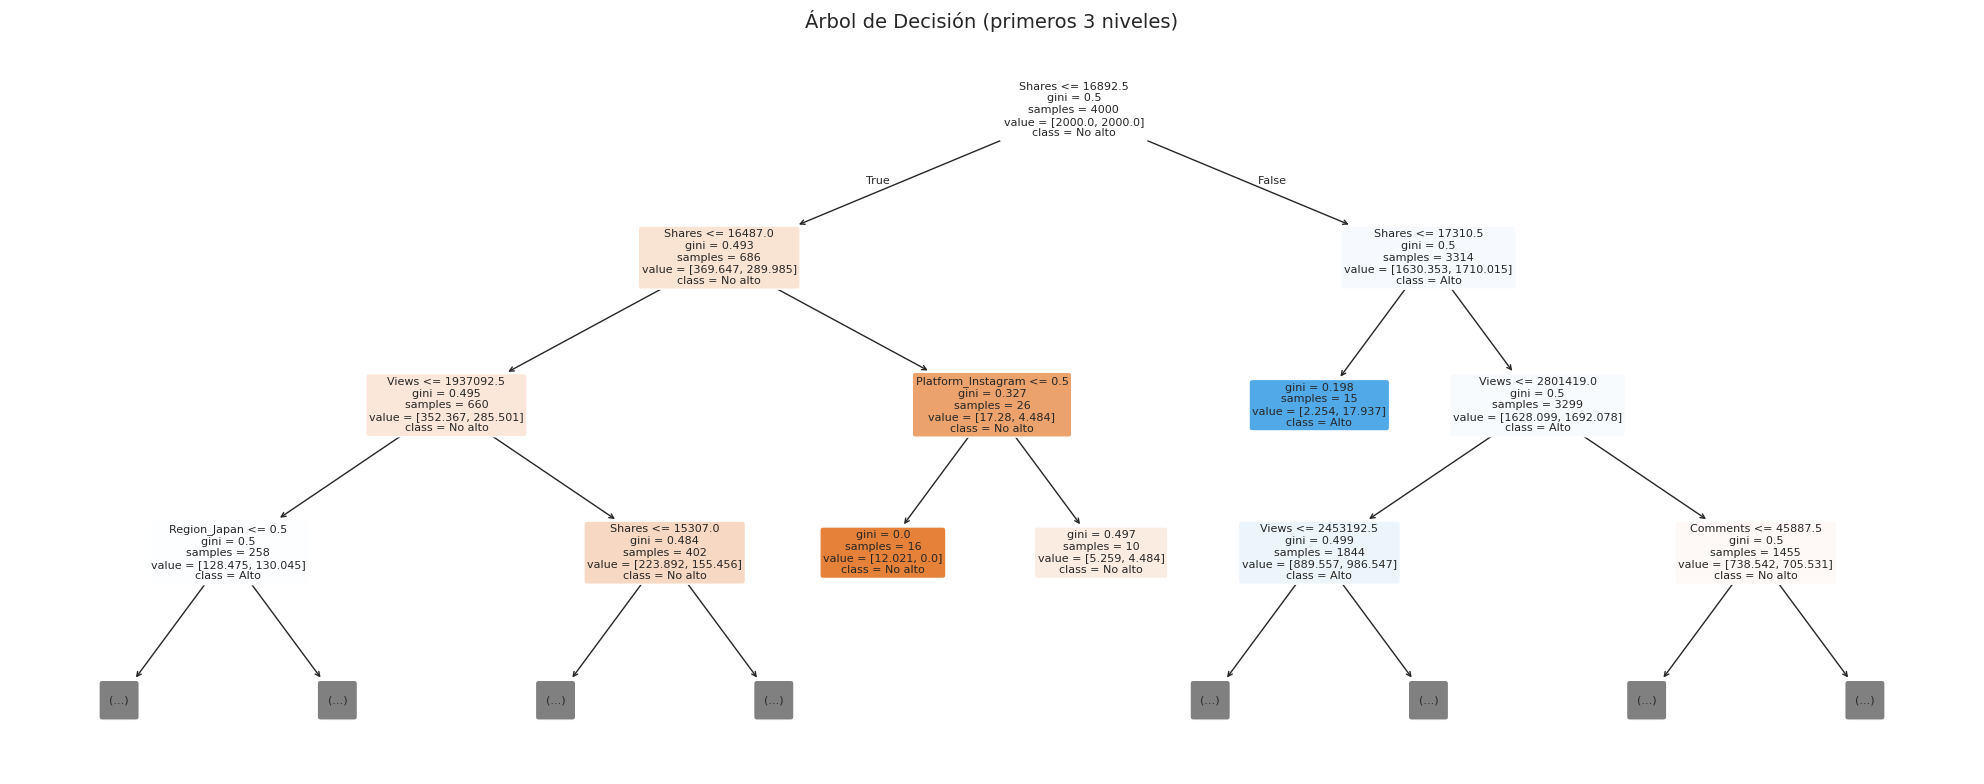

In [ ]:
# 6.2  Visualización del árbol
fig, ax = plt.subplots(figsize=(20, 8))
plot_tree(
    pipe_dt_v.named_steps['clf'],
    feature_names=feature_names_v,
    class_names=['No alto', 'Alto'],
    filled=True, rounded=True, fontsize=8, ax=ax,
    max_depth=3  # Mostrar solo 3 niveles para legibilidad
)
ax.set_title('Árbol de Decisión (primeros 3 niveles)', fontsize=14)
plt.tight_layout()
plt.show()

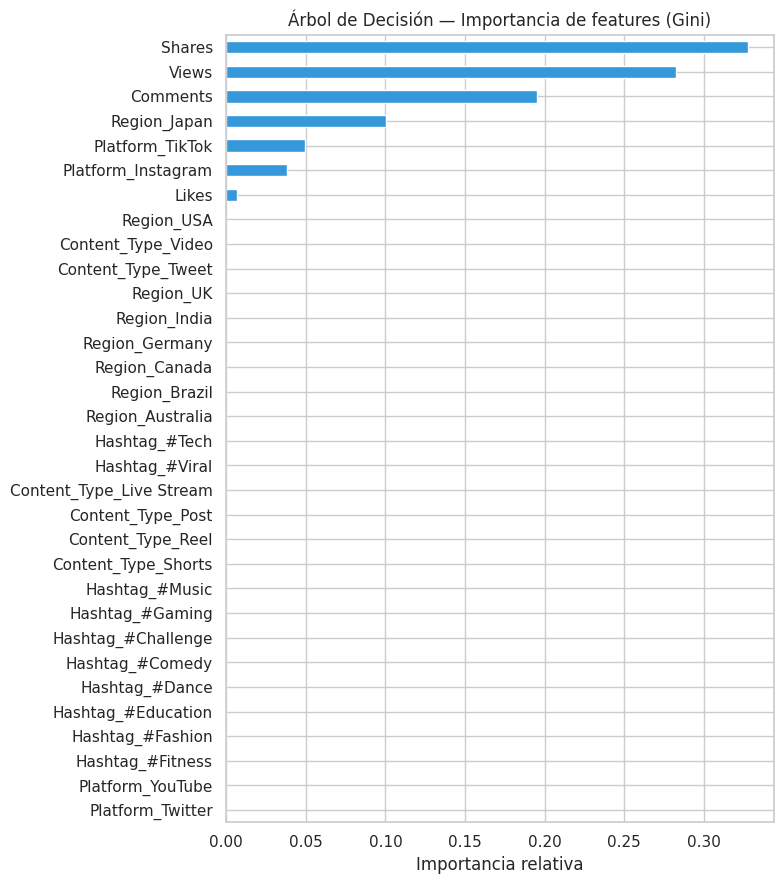

In [ ]:
# 6.3  Importancia de features (Gini importance)
importances_v = pd.Series(
    pipe_dt_v.named_steps['clf'].feature_importances_,
    index=feature_names_v
).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 9))
importances_v.plot(kind='barh', ax=ax, color='#3498db')
ax.set_title('Árbol de Decisión — Importancia de features (Gini)')
ax.set_xlabel('Importancia relativa')
plt.tight_layout()
plt.show()

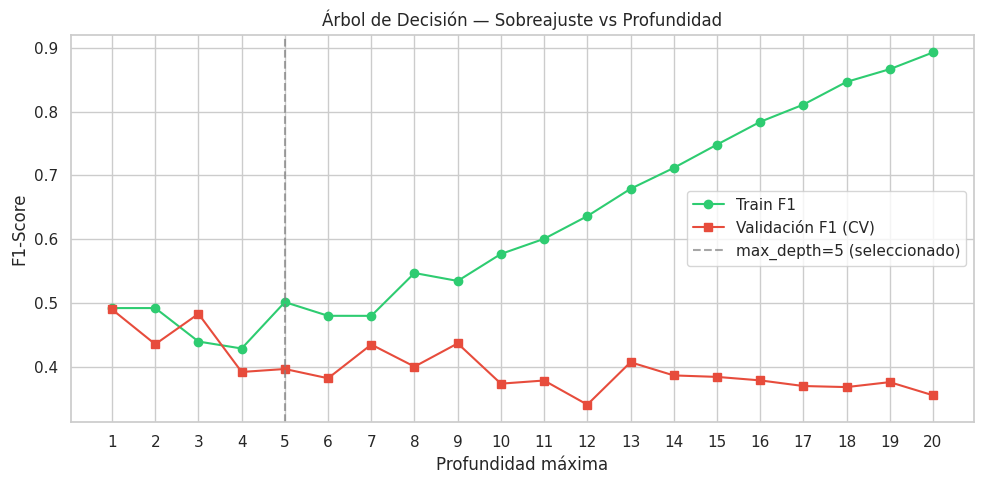

Observación: cuando la brecha entre train y validación crece,
el modelo está sobreajustando (memorizando el train set).


In [ ]:
# 6.4  Efecto de la profundidad en sobreajuste/subajuste
depths = range(1, 21)
train_scores_v = []
val_scores_v = []

for d in depths:
    dt = Pipeline([
        ('prep', build_preprocessor(scale=False)),
        ('clf', DecisionTreeClassifier(max_depth=d, class_weight='balanced',
                                       random_state=RANDOM_STATE))
    ])
    dt.fit(X_train_v, y_train_v)
    train_scores_v.append(f1_score(y_train_v, dt.predict(X_train_v)))
    cv_s = cross_val_score(dt, X_train_v, y_train_v, cv=cv_v, scoring='f1')
    val_scores_v.append(cv_s.mean())

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(depths, train_scores_v, 'o-', label='Train F1', color='#2ecc71')
ax.plot(depths, val_scores_v, 's-', label='Validación F1 (CV)', color='#e74c3c')
ax.axvline(x=5, color='gray', linestyle='--', alpha=0.7, label='max_depth=5 (seleccionado)')
ax.set_xlabel('Profundidad máxima')
ax.set_ylabel('F1-Score')
ax.set_title('Árbol de Decisión — Sobreajuste vs Profundidad')
ax.legend()
ax.set_xticks(depths)
plt.tight_layout()
plt.show()

print('Observación: cuando la brecha entre train y validación crece,')
print('el modelo está sobreajustando (memorizando el train set).')

---
### Ejercicio 3 · 7. Modelo 3 — Support Vector Machine (SVM)

**Fundamento:** Busca el hiperplano que maximiza el margen de separación entre clases. Con funciones kernel puede manejar fronteras no lineales. Es **sensible a la escala** de las features.

In [ ]:
# 7.1  Comparación de kernels
kernels = ['linear', 'rbf', 'poly']
svm_results_v = {}

for kernel in kernels:
    pipe_svm_k = Pipeline([
        ('prep', build_preprocessor(scale=True)),
        ('clf', SVC(kernel=kernel, class_weight='balanced',
                     random_state=RANDOM_STATE, probability=True))
    ])
    scores = cross_val_score(pipe_svm_k, X_train_v, y_train_v, cv=cv_v, scoring='f1')
    svm_results_v[kernel] = scores
    print(f'SVM ({kernel:6s}) — F1 CV: {scores.mean():.4f} ± {scores.std():.4f}')

# Seleccionar el mejor kernel
best_kernel_v = max(svm_results_v, key=lambda k: svm_results_v[k].mean())
print(f'\nMejor kernel: {best_kernel_v}')

SVM (linear) — F1 CV: 0.4079 ± 0.0594
SVM (rbf   ) — F1 CV: 0.3911 ± 0.0219
SVM (poly  ) — F1 CV: 0.3911 ± 0.0153

Mejor kernel: linear


In [ ]:
# 7.2  Entrenamiento con el mejor kernel
pipe_svm_v = Pipeline([
    ('prep', build_preprocessor(scale=True)),
    ('clf', SVC(kernel=best_kernel_v, class_weight='balanced',
                 random_state=RANDOM_STATE, probability=True))
])

pipe_svm_v.fit(X_train_v, y_train_v)
y_pred_svm_v = pipe_svm_v.predict(X_test_v)
scores_svm_v = svm_results_v[best_kernel_v]

In [ ]:
# 7.3  Impacto de la estandarización en SVM
# SVM SIN estandarizar (solo One-Hot en las categóricas)
svm_no_scale_v = Pipeline([
    ('prep', build_preprocessor(scale=False)),
    ('clf', SVC(kernel=best_kernel_v, class_weight='balanced',
                 random_state=RANDOM_STATE,
                 max_iter=100000))  # tope de iteraciones: sin escalar (Views ~ 10^6) el solver casi no converge
])
scores_no_scale_v = cross_val_score(svm_no_scale_v, X_train_v, y_train_v, cv=cv_v, scoring='f1')

print('Impacto de la estandarización en SVM:')
print(f'  CON StandardScaler: F1 = {scores_svm_v.mean():.4f}')
print(f'  SIN StandardScaler: F1 = {scores_no_scale_v.mean():.4f}')
dif_v = (scores_svm_v.mean() - scores_no_scale_v.mean()) * 100
print(f'  Diferencia: {dif_v:+.2f} puntos porcentuales')
if dif_v > 2:
    print('\n→ La estandarización es CRÍTICA para modelos basados en distancias.')
else:
    print('\n→ En este dataset la diferencia es pequeña (< 2 pp): como las features casi no tienen')
    print('  señal predictiva (ver sección 9), ni el escalado puede mejorar mucho el resultado.')
    print('  Aun así, sin escalar Views (~10^6) domina la métrica de distancia y el solver casi no converge')
    print('  (por eso se limita max_iter); la estandarización sigue siendo la práctica correcta.')

Impacto de la estandarización en SVM:
  CON StandardScaler: F1 = 0.4079
  SIN StandardScaler: F1 = 0.3997
  Diferencia: +0.82 puntos porcentuales

→ En este dataset la diferencia es pequeña (< 2 pp): como las features casi no tienen
  señal predictiva (ver sección 9), ni el escalado puede mejorar mucho el resultado.
  Aun así, sin escalar Views (~10^6) domina la métrica de distancia y el solver casi no converge
  (por eso se limita max_iter); la estandarización sigue siendo la práctica correcta.


---
### Ejercicio 3 · 8. Modelo 4 — K-Nearest Neighbors (KNN)

**Fundamento:** Clasifica según la mayoría de votos de los K vecinos más cercanos. No paramétrico, sensible a la escala y a la dimensionalidad. El valor de K controla el trade-off bias-varianza.

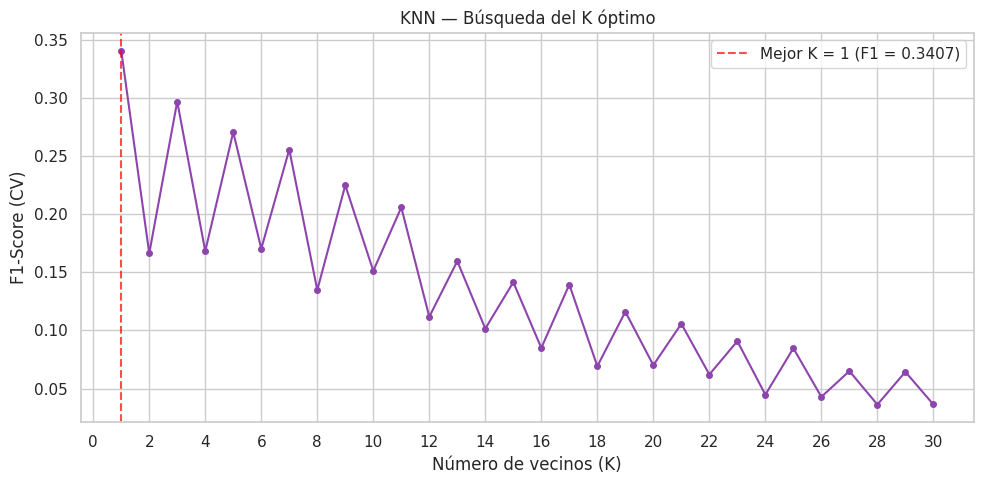

K óptimo: 1


In [ ]:
# 8.1  Búsqueda del K óptimo
k_range = range(1, 31)
k_scores_v = []

for k in k_range:
    pipe_knn_k = Pipeline([
        ('prep', build_preprocessor(scale=True)),
        ('clf', KNeighborsClassifier(n_neighbors=k))
    ])
    scores = cross_val_score(pipe_knn_k, X_train_v, y_train_v, cv=cv_v, scoring='f1')
    k_scores_v.append(scores.mean())

best_k_v = k_range[np.argmax(k_scores_v)]

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(k_range, k_scores_v, 'o-', markersize=4, color='#8e44ad')
ax.axvline(x=best_k_v, color='red', linestyle='--', alpha=0.7,
           label=f'Mejor K = {best_k_v} (F1 = {max(k_scores_v):.4f})')
ax.set_xlabel('Número de vecinos (K)')
ax.set_ylabel('F1-Score (CV)')
ax.set_title('KNN — Búsqueda del K óptimo')
ax.legend()
ax.set_xticks(range(0, 31, 2))
plt.tight_layout()
plt.show()

print(f'K óptimo: {best_k_v}')

In [ ]:
# 8.2  Entrenamiento con K óptimo
pipe_knn_v = Pipeline([
    ('prep', build_preprocessor(scale=True)),
    ('clf', KNeighborsClassifier(n_neighbors=best_k_v))
])

scores_knn_v = cross_val_score(pipe_knn_v, X_train_v, y_train_v, cv=cv_v, scoring='f1')
print(f'KNN (K={best_k_v}) — F1 CV: {scores_knn_v.mean():.4f} ± {scores_knn_v.std():.4f}')

pipe_knn_v.fit(X_train_v, y_train_v)
y_pred_knn_v = pipe_knn_v.predict(X_test_v)

KNN (K=1) — F1 CV: 0.3407 ± 0.0270


---
### Ejercicio 3 · 9. Análisis comparativo de modelos

In [ ]:
# 9.1  Tabla resumen
models_v = {
    'Logistic Regression': (pipe_lr_v, y_pred_lr_v, scores_lr_v),
    'Decision Tree':       (pipe_dt_v, y_pred_dt_v, scores_dt_v),
    f'SVM ({best_kernel_v})': (pipe_svm_v, y_pred_svm_v, scores_svm_v),
    f'KNN (K={best_k_v})':   (pipe_knn_v, y_pred_knn_v, scores_knn_v)
}

summary_v = []
for name, (pipe, y_pred, cv_scores) in models_v.items():
    summary_v.append({
        'Modelo': name,
        'F1 CV (mean)': f'{cv_scores.mean():.4f}',
        'F1 CV (std)': f'{cv_scores.std():.4f}',
        'Accuracy Test': f'{accuracy_score(y_test_v, y_pred):.4f}',
        'F1 Test': f'{f1_score(y_test_v, y_pred):.4f}'
    })

summary_df_v = pd.DataFrame(summary_v)
print('='*80)
print('COMPARACIÓN DE MODELOS')
print('='*80)
summary_df_v

COMPARACIÓN DE MODELOS


,Modelo,F1 CV (mean),F1 CV (std),Accuracy Test,F1 Test
0,Logistic Regression,0.4013,0.0282,0.4920,0.3909
1,Decision Tree,0.4052,0.0393,0.4320,0.4631
2,SVM (linear),0.4079,0.0594,0.4580,0.4185
3,KNN (K=1),0.3407,0.0270,0.5400,0.3093


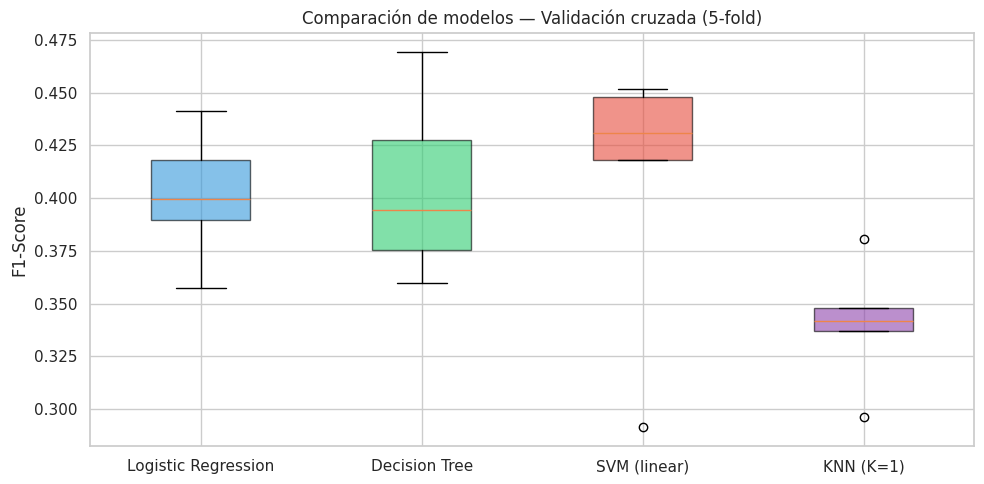

In [ ]:
# 9.2  Boxplot comparativo de validación cruzada
fig, ax = plt.subplots(figsize=(10, 5))
cv_data = [scores_lr_v, scores_dt_v, scores_svm_v, scores_knn_v]
labels = list(models_v.keys())
bp = ax.boxplot(cv_data, tick_labels=labels, patch_artist=True)
colors_box = ['#3498db', '#2ecc71', '#e74c3c', '#8e44ad']
for patch, color in zip(bp['boxes'], colors_box):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)
ax.set_ylabel('F1-Score')
ax.set_title('Comparación de modelos — Validación cruzada (5-fold)')
plt.tight_layout()
plt.show()

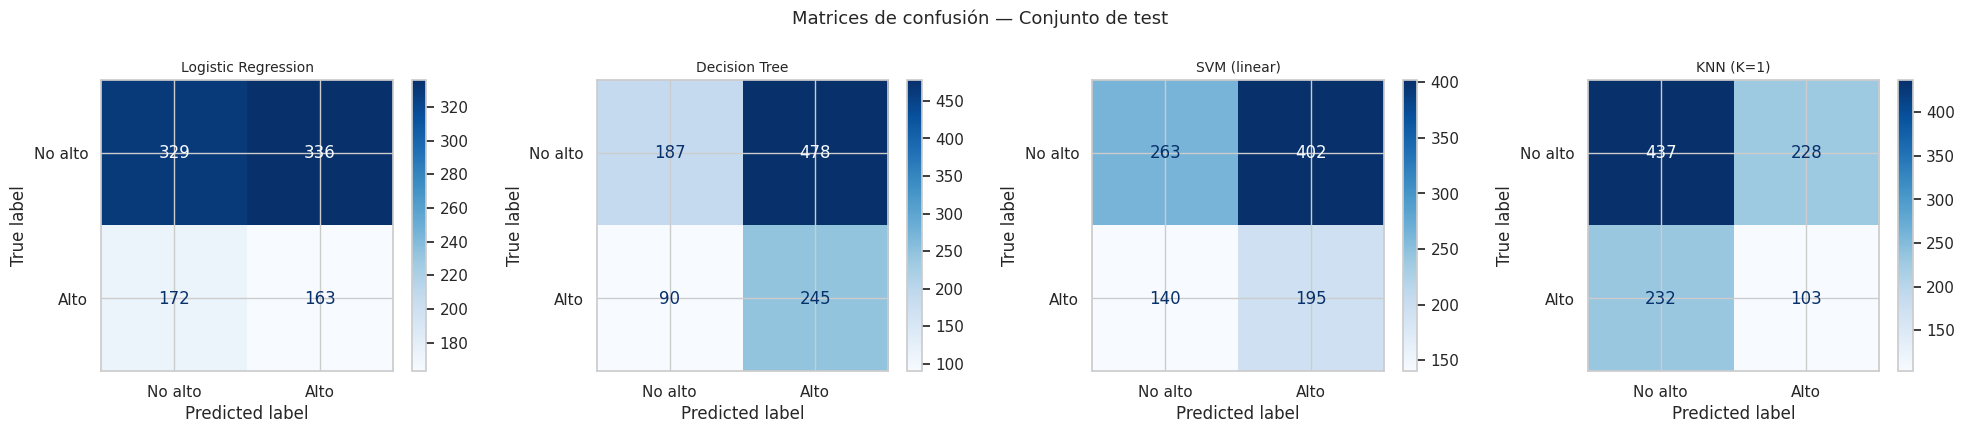

In [ ]:
# 9.3  Matrices de confusión comparativas
fig, axes = plt.subplots(1, 4, figsize=(20, 4))

for ax, (name, (pipe, y_pred, _)) in zip(axes, models_v.items()):
    ConfusionMatrixDisplay.from_predictions(
        y_test_v, y_pred,
        display_labels=['No alto', 'Alto'],
        cmap='Blues', ax=ax
    )
    ax.set_title(name, fontsize=10)

fig.suptitle('Matrices de confusión — Conjunto de test', fontsize=13, y=1.03)
plt.tight_layout()
plt.show()

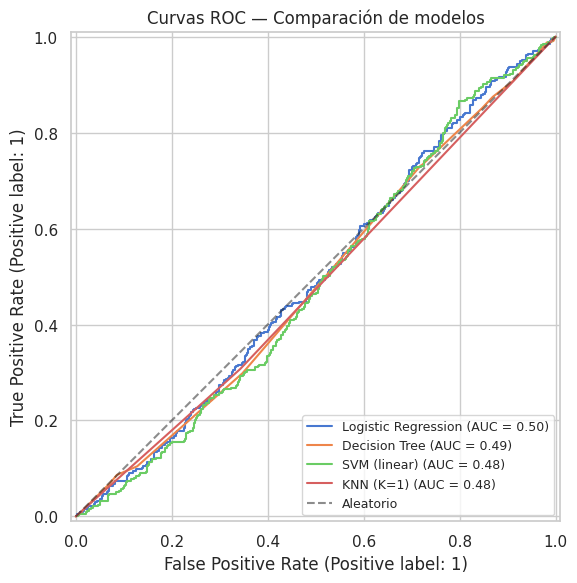

In [ ]:
# 9.4  Curvas ROC comparativas
fig, ax = plt.subplots(figsize=(7, 6))

for name, (pipe, _, _) in models_v.items():
    RocCurveDisplay.from_estimator(pipe, X_test_v, y_test_v, ax=ax, name=name)

ax.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Aleatorio')
ax.set_title('Curvas ROC — Comparación de modelos')
ax.legend(loc='lower right', fontsize=9)
plt.tight_layout()
plt.show()

In [ ]:
# 9.5  Classification report detallado del mejor modelo
best_model_name_v = max(models_v, key=lambda k: float(models_v[k][2].mean()))
best_pipe_v, best_pred_v, best_cv_v = models_v[best_model_name_v]

print(f'\nMejor modelo: {best_model_name_v}')
print('='*60)
print(classification_report(y_test_v, best_pred_v,
                             target_names=['No alto', 'Alto']))


Mejor modelo: SVM (linear)
              precision    recall  f1-score   support

     No alto       0.65      0.40      0.49       665
        Alto       0.33      0.58      0.42       335

    accuracy                           0.46      1000
   macro avg       0.49      0.49      0.46      1000
weighted avg       0.54      0.46      0.47      1000



---
### Ejercicio 3 · 10. Resumen comparativo

| Modelo | Fortalezas | Limitaciones | ¿Cuándo usarlo? |
|---|---|---|---|
| **Regresión Logística** | Rápido, interpretable (coeficientes), probabilístico | Asume relación lineal entre features y log-odds | Baseline; cuando la interpretabilidad es prioritaria |
| **Árbol de Decisión** | Interpretable (visualización), maneja no linealidades, no requiere estandarización | Propenso a sobreajuste; inestable (pequeños cambios en datos alteran el árbol) | Cuando se necesitan reglas explicables; como parte de ensambles |
| **SVM** | Efectivo en alta dimensionalidad; flexible con kernels | Sensible a la escala; costoso en datasets grandes; difícil de interpretar | Datasets de tamaño moderado con fronteras complejas |
| **KNN** | Simple, no paramétrico, adaptable | Lento en predicción (distancias contra todo el train); sensible a escala y dimensionalidad | Datasets pequeños-medianos; cuando la frontera es irregular |

#### Hallazgos con el dataset *Viral Social Media Trends*

**1. Las features no predicen el engagement.** Los cuatro modelos quedan en el nivel del azar: el **AUC es ≈ 0.48–0.50** en las curvas ROC y los F1 de validación cruzada están entre 0.34 y 0.41. Como referencia, una regla trivial que predijera siempre "Alto" obtendría F1 ≈ 0.50 (a costa de una accuracy de 33.5 %). Los boxplots (3.2) y las tasas por categoría (3.2b) ya lo anticipaban (y la correlación de 3.3 muestra que las numéricas son prácticamente independientes entre sí, |r| < 0.02): las medias de `Views`, `Likes`, `Shares` y `Comments` son casi idénticas entre clases, y la tasa de engagement Alto por plataforma, hashtag, tipo de contenido o región se mantiene cerca del 33.5 % global (rango ≈ 29–37 %). Las diferencias observadas son compatibles con ruido muestral.

**2. Las diferencias entre modelos no son significativas.** Regresión Logística, Árbol y SVM lineal (F1 CV ≈ 0.40–0.41) se solapan por completo dentro de una desviación estándar (0.03–0.06). El "mejor" modelo por F1 CV (SVM lineal) y el mejor por F1 en test (Árbol) son distintos, lo que confirma que el orden depende de la partición y no de una ventaja real.

**3. El Árbol de Decisión sobreajusta claramente.** En la curva de profundidad (6.4) el F1 de entrenamiento sube hasta ≈ 0.9 con `max_depth=20`, mientras que el F1 de validación se mantiene o baja (≈ 0.35–0.40): el árbol memoriza ruido. Las importancias de Gini (6.3) se concentran en las numéricas continuas (`Shares`, `Views`, `Comments`), pero esto es un sesgo conocido de los árboles —tienen muchos más puntos de corte posibles que una variable binaria— y no una relación real, dado que el AUC es ≈ 0.5. En la Regresión Logística (5.2) ningún coeficiente estandarizado supera |0.18| en magnitud.

**4. KNN es el más afectado.** El K "óptimo" resultó ser **K = 1** (F1 CV ≈ 0.34), señal típica de que no hay estructura local que aprovechar: con K mayor el modelo tiende a predecir siempre la clase mayoritaria (F1 → 0). Su accuracy de test (0.54, la más alta) es engañosa: se debe a que favorece la clase mayoritaria, mientras que su F1 en la clase "Alto" es el más bajo (≈ 0.31).

**5. Preprocesamiento.** Se necesitó un `ColumnTransformer` (estandarización de las 4 numéricas + One-Hot de las 4 categóricas → 32 columnas). Las escalas difieren en varios órdenes de magnitud (`Views` hasta 5·10⁶ vs `Comments` hasta 5·10⁴). En este dataset el efecto de estandarizar el SVM es pequeño (≈ +0.8 pp), porque no hay señal que el escalado pueda revelar; aun así es la práctica correcta.

**Conclusión.** Con las variables disponibles, ninguno de los cuatro modelos permite predecir de forma fiable si una publicación tendrá engagement alto: el problema no es de elección de algoritmo, sino de **información**. Para mejorar el desempeño habría que incorporar variables con poder explicativo real (por ejemplo, hora de publicación, número de seguidores del autor, duración del contenido, tasas *likes/views* calculadas con cuidado de no introducir fuga de información, etc.). Si el objetivo es solo comparar algoritmos, se recomienda la Regresión Logística por ser el modelo más simple, estable y probabilístico entre los que rinden igual.

---
*Ingeniería del Conocimiento (ISO56B) — UNCP — 2026-II*